In [3]:
from pathlib import Path

import numpy as np
import pandas as pd


def generate_fea_stress_surrogate_dataset(n_samples=1000, seed=42):
    """Generate synthetic plate-with-hole stress data from Kirsch/finite-width formulas."""
    rng = np.random.default_rng(seed)

    # Geometry and loading ranges used by the surrogate generator.
    width_mm = rng.uniform(100.0, 300.0, n_samples)
    hole_to_width = rng.uniform(0.05, 0.35, n_samples)
    hole_diameter_mm = width_mm * hole_to_width
    thickness_mm = rng.uniform(2.0, 12.0, n_samples)
    nominal_stress_MPa = rng.uniform(50.0, 300.0, n_samples)

    # Kirsch solution for an infinite plate: Kt = 3.
    kirsch_Kt = np.full(n_samples, 3.0)
    kirsch_peak_stress_MPa = kirsch_Kt * nominal_stress_MPa

    # Finite-width correction for a centered circular hole:
    # Kt = 3 - 3.14(D/W) + 3.667(D/W)^2 - 1.527(D/W)^3.
    finite_width_Kt = (
        3.0
        - 3.14 * hole_to_width
        + 3.667 * hole_to_width**2
        - 1.527 * hole_to_width**3
    )
    finite_width_peak_stress_MPa = finite_width_Kt * nominal_stress_MPa

    # Small deterministic surrogate discrepancy emulates FEA-vs-closed-form variation.
    fea_noise = rng.normal(loc=0.0, scale=0.015, size=n_samples)
    fea_peak_stress_MPa = finite_width_peak_stress_MPa * (1.0 + fea_noise)

    return pd.DataFrame(
        {
            "sample_id": np.arange(1, n_samples + 1),
            "width_mm": width_mm,
            "hole_diameter_mm": hole_diameter_mm,
            "thickness_mm": thickness_mm,
            "nominal_stress_MPa": nominal_stress_MPa,
            "hole_to_width": hole_to_width,
            "kirsch_Kt": kirsch_Kt,
            "finite_width_Kt": finite_width_Kt,
            "kirsch_peak_stress_MPa": kirsch_peak_stress_MPa,
            "finite_width_peak_stress_MPa": finite_width_peak_stress_MPa,
            "fea_peak_stress_MPa": fea_peak_stress_MPa,
        }
    )


In [5]:
# Generate 1,500 samples with the generator's default seed.
df = generate_fea_stress_surrogate_dataset(n_samples=1500)

# Save the resulting DataFrame in the project directory.
csv_path = Path("fea_stress_surrogate_dataset.csv")
df.to_csv(csv_path, index=False)

print(f"Dataset shape: {df.shape}")
print(f"Saved to: {csv_path.resolve()}")
print("\nHead:")
print(df.iloc[:5].to_string(index=False))
print("\nDescriptive statistics:")
print(df.describe().to_string())

df

Dataset shape: (1500, 11)
Saved to: /datasets/_deepnote_work/fea_stress_surrogate_dataset.csv

Head:
 sample_id   width_mm  hole_diameter_mm  thickness_mm  nominal_stress_MPa  hole_to_width  kirsch_Kt  finite_width_Kt  kirsch_peak_stress_MPa  finite_width_peak_stress_MPa  fea_peak_stress_MPa
         1 254.791210         64.094323     10.292211           54.712895       0.251556        3.0         2.417855              164.138684                    132.287868           130.230142
         2 187.775688         63.501248      7.940960          163.755440       0.338176        3.0         2.298440              491.266320                    376.382045           379.106875
         3 271.719584         43.821222      4.448547          204.518460       0.161274        3.0         2.582571              613.555379                    528.183482           523.370180
         4 239.473606         42.512439      9.456750          165.098897       0.177525        3.0         2.549595              4

,sample_id,width_mm,hole_diameter_mm,thickness_mm,nominal_stress_MPa,hole_to_width,kirsch_Kt,finite_width_Kt,kirsch_peak_stress_MPa,finite_width_peak_stress_MPa,fea_peak_stress_MPa
0,1,254.791210,64.094323,10.292211,54.712895,0.251556,3.0,2.417855,164.138684,132.287868,130.230142
1,2,187.775688,63.501248,7.940960,163.755440,0.338176,3.0,2.298440,491.266320,376.382045,379.106875
2,3,271.719584,43.821222,4.448547,204.518460,0.161274,3.0,2.582571,613.555379,528.183482,523.370180
3,4,239.473606,42.512439,9.456750,165.098897,0.177525,3.0,2.549595,495.296690,420.935364,410.523109
4,5,118.835470,34.894478,2.844809,82.661314,0.293637,3.0,2.355498,247.983942,194.708537,193.868941
...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,227.587349,43.666309,5.575982,144.070186,0.191866,3.0,2.521747,432.210558,363.308532,361.341116
1496,1497,271.245801,66.871358,6.789184,195.169417,0.246534,3.0,2.425879,585.508251,473.457371,463.921320
1497,1498,226.213089,25.567992,6.939097,253.982766,0.113026,3.0,2.689739,761.948297,683.147269,690.028115
1498,1499,169.534727,58.281457,10.561951,265.309336,0.343773,3.0,2.291881,795.928007,608.057401,602.915743


In [7]:
expected_columns = [
    "sample_id",
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "hole_to_width",
    "kirsch_Kt",
    "finite_width_Kt",
    "kirsch_peak_stress_MPa",
    "finite_width_peak_stress_MPa",
    "fea_peak_stress_MPa",
]

saved_df = pd.read_csv(csv_path)
assert csv_path.exists()
assert saved_df.shape == (1500, 11)
assert list(saved_df.columns) == expected_columns

print(f"Validated CSV: {csv_path.resolve()}")
print(f"Validated shape: {saved_df.shape}")
print(f"Validated columns: {list(saved_df.columns)}")

Validated CSV: /datasets/_deepnote_work/fea_stress_surrogate_dataset.csv
Validated shape: (1500, 11)
Validated columns: ['sample_id', 'width_mm', 'hole_diameter_mm', 'thickness_mm', 'nominal_stress_MPa', 'hole_to_width', 'kirsch_Kt', 'finite_width_Kt', 'kirsch_peak_stress_MPa', 'finite_width_peak_stress_MPa', 'fea_peak_stress_MPa']


## Geometry Validation and Stratified Train/Val/Test Split

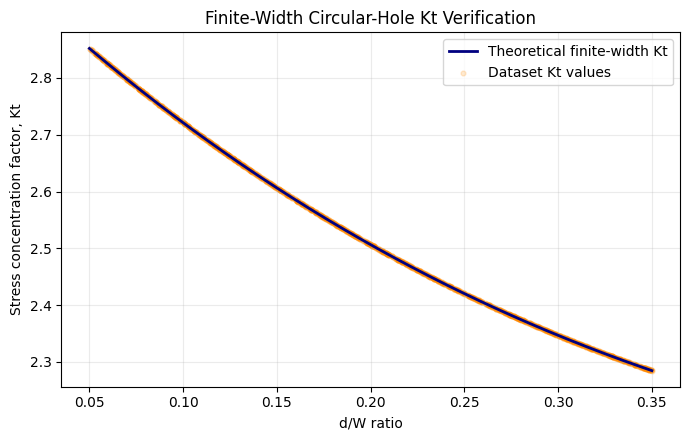

Source: fea_stress_surrogate_dataset.csv | rows=1500
Geometry validation: PASS | d/W source='hole_to_width' | max Kt error=1.33e-15
Split sizes and d/W distributions:
split  rows share d_over_w_min d_over_w_mean d_over_w_max
train  1050 70.0%       0.0502        0.2000       0.3499
  val   220 14.7%       0.0512        0.2001       0.3491
 test   230 15.3%       0.0522        0.1989       0.3483
Columns (12): ['sample_id', 'width_mm', 'hole_diameter_mm', 'thickness_mm', 'nominal_stress_MPa', 'hole_to_width', 'kirsch_Kt', 'finite_width_Kt', 'kirsch_peak_stress_MPa', 'finite_width_peak_stress_MPa', 'fea_peak_stress_MPa', 'd_over_w_ratio']
Exported: train_fea_stress.csv, val_fea_stress.csv, test_fea_stress.csv


,split,rows,share,d_over_w_min,d_over_w_mean,d_over_w_max
0,train,1050,0.700000,0.050170,0.199961,0.349930
1,val,220,0.146667,0.051168,0.200125,0.349121
2,test,230,0.153333,0.052245,0.198861,0.348281


In [9]:
import matplotlib.pyplot as plt

# Load the existing dataset and resolve the requested d/W schema.
workflow_csv_path = Path("fea_stress_surrogate_dataset.csv")
workflow_df = pd.read_csv(workflow_csv_path)

required_columns = [
    "sample_id",
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "finite_width_Kt",
    "fea_peak_stress_MPa",
]
missing_columns = [column for column in required_columns if column not in workflow_df.columns]
assert not missing_columns, f"Missing required columns: {missing_columns}"

# The source already contains hole_to_width; retain it and expose the workflow name.
if "d_over_w_ratio" not in workflow_df.columns:
    workflow_df["d_over_w_ratio"] = workflow_df["hole_to_width"]
else:
    workflow_df["d_over_w_ratio"] = workflow_df["d_over_w_ratio"].fillna(workflow_df["hole_to_width"])

# Geometry validation: d/W must agree with the physical dimensions and remain in the generator range.
calculated_d_over_w = workflow_df["hole_diameter_mm"] / workflow_df["width_mm"]
assert np.allclose(workflow_df["d_over_w_ratio"], calculated_d_over_w, rtol=0, atol=1e-12)
assert workflow_df["d_over_w_ratio"].between(0.05, 0.35).all()
assert (workflow_df[["width_mm", "hole_diameter_mm", "thickness_mm"]] > 0).all().all()

# Theoretical finite-width Kt verification against the dataset's stored Kt.
verification_kt = (
    3.0
    - 3.14 * workflow_df["d_over_w_ratio"]
    + 3.667 * workflow_df["d_over_w_ratio"] ** 2
    - 1.527 * workflow_df["d_over_w_ratio"] ** 3
)
kt_max_abs_error = (verification_kt - workflow_df["finite_width_Kt"]).abs().max()
assert kt_max_abs_error < 1e-12

kt_curve_ratio = np.linspace(0.05, 0.35, 300)
kt_curve = 3.0 - 3.14 * kt_curve_ratio + 3.667 * kt_curve_ratio**2 - 1.527 * kt_curve_ratio**3
plt.figure(figsize=(7, 4.5))
plt.plot(kt_curve_ratio, kt_curve, color="navy", linewidth=2, label="Theoretical finite-width Kt")
plt.scatter(
    workflow_df["d_over_w_ratio"],
    workflow_df["finite_width_Kt"],
    s=12,
    alpha=0.18,
    color="darkorange",
    label="Dataset Kt values",
)
plt.xlabel("d/W ratio")
plt.ylabel("Stress concentration factor, Kt")
plt.title("Finite-Width Circular-Hole Kt Verification")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Stratify on d/W quantile bins, then allocate each stratum 70/15/15.
# Quantile bins preserve the d/W distribution while avoiding the schema mismatch.
workflow_df["d_over_w_stratum"] = pd.qcut(
    workflow_df["d_over_w_ratio"], q=10, labels=False, duplicates="drop"
)
stratified_rng = np.random.default_rng(42)
train_parts, val_parts, test_parts = [], [], []
for _, stratum_df in workflow_df.groupby("d_over_w_stratum", sort=True):
    shuffled_indices = stratified_rng.permutation(stratum_df.index.to_numpy())
    n_rows = len(shuffled_indices)
    n_train = int(round(n_rows * 0.70))
    n_val = int(round(n_rows * 0.15))
    n_test = n_rows - n_train - n_val
    train_parts.append(workflow_df.loc[shuffled_indices[:n_train]])
    val_parts.append(workflow_df.loc[shuffled_indices[n_train:n_train + n_val]])
    test_parts.append(workflow_df.loc[shuffled_indices[n_train + n_val:]])

train_fea = pd.concat(train_parts).sample(frac=1, random_state=42).reset_index(drop=True)
val_fea = pd.concat(val_parts).sample(frac=1, random_state=42).reset_index(drop=True)
test_fea = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)

# Keep the stratification helper internal to the split; exported files contain the data schema.
export_columns = [column for column in workflow_df.columns if column != "d_over_w_stratum"]
train_fea = train_fea[export_columns]
val_fea = val_fea[export_columns]
test_fea = test_fea[export_columns]

train_path = Path("train_fea_stress.csv")
val_path = Path("val_fea_stress.csv")
test_path = Path("test_fea_stress.csv")
train_fea.to_csv(train_path, index=False)
val_fea.to_csv(val_path, index=False)
test_fea.to_csv(test_path, index=False)

# Concise validation report.
assert len(train_fea) + len(val_fea) + len(test_fea) == len(workflow_df)
assert set(train_fea["sample_id"]).isdisjoint(val_fea["sample_id"])
assert set(train_fea["sample_id"]).isdisjoint(test_fea["sample_id"])
assert set(val_fea["sample_id"]).isdisjoint(test_fea["sample_id"])
assert list(train_fea.columns) == export_columns
assert list(val_fea.columns) == export_columns
assert list(test_fea.columns) == export_columns

split_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train_fea), len(val_fea), len(test_fea)],
        "share": [len(train_fea), len(val_fea), len(test_fea)],
        "d_over_w_min": [train_fea["d_over_w_ratio"].min(), val_fea["d_over_w_ratio"].min(), test_fea["d_over_w_ratio"].min()],
        "d_over_w_mean": [train_fea["d_over_w_ratio"].mean(), val_fea["d_over_w_ratio"].mean(), test_fea["d_over_w_ratio"].mean()],
        "d_over_w_max": [train_fea["d_over_w_ratio"].max(), val_fea["d_over_w_ratio"].max(), test_fea["d_over_w_ratio"].max()],
    }
)
split_summary["share"] = split_summary["share"] / len(workflow_df)
print(f"Source: {workflow_csv_path} | rows={len(workflow_df)}")
print(f"Geometry validation: PASS | d/W source='hole_to_width' | max Kt error={kt_max_abs_error:.2e}")
print("Split sizes and d/W distributions:")
print(split_summary.to_string(index=False, formatters={"share": "{:.1%}".format, "d_over_w_min": "{:.4f}".format, "d_over_w_mean": "{:.4f}".format, "d_over_w_max": "{:.4f}".format}))
print(f"Columns ({len(export_columns)}): {export_columns}")
print(f"Exported: {train_path}, {val_path}, {test_path}")

split_summary

Schema adaptation notes
Requested schema columns: ['plate_width_mm', 'hole_radius_mm', 'plate_thickness_mm', 'youngs_modulus_gpa', 'poissons_ratio', 'tensile_force_kn', 'eval_radial_ratio', 'von_mises_target_mpa']
Unavailable requested columns: ['plate_width_mm', 'hole_radius_mm', 'plate_thickness_mm', 'youngs_modulus_gpa', 'poissons_ratio', 'tensile_force_kn', 'eval_radial_ratio', 'von_mises_target_mpa']
Adapted input features (5): ['width_mm', 'hole_diameter_mm', 'thickness_mm', 'nominal_stress_MPa', 'd_over_w_ratio']
Adapted target: fea_peak_stress_MPa
Excluded IDs/duplicate or target-derived columns: ['sample_id', 'hole_to_width', 'kirsch_Kt', 'finite_width_Kt', 'kirsch_peak_stress_MPa', 'finite_width_peak_stress_MPa']
Leakage control: only the five physical/input columns above are passed to either model.
Split sizes: train=1050, validation=220, test=230
PyTorch MLP training stopped at epoch 998 (best validation MSE=0.002126).

Ranked Random Forest feature importances:
           f

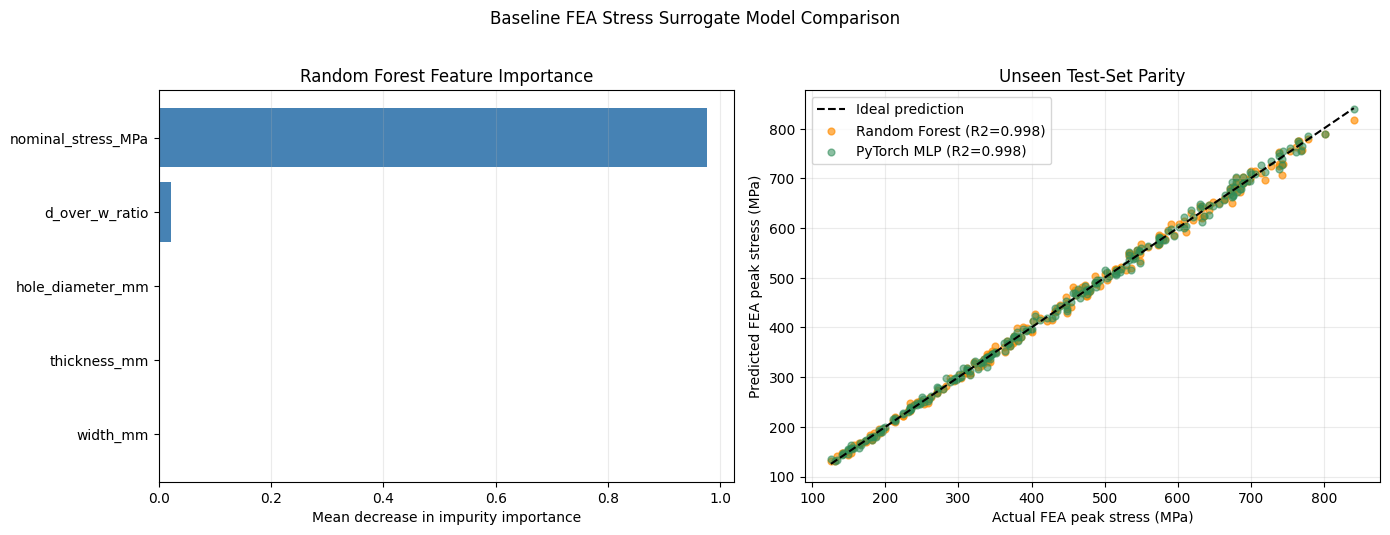

In [11]:
# Baseline FEA surrogate modeling and model comparison adapted to the project split schema.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

# The requested schema is not present in these files. Use only the available,
# non-target physical/input columns and exclude IDs and target-derived columns.
requested_columns = [
    "plate_width_mm",
    "hole_radius_mm",
    "plate_thickness_mm",
    "youngs_modulus_gpa",
    "poissons_ratio",
    "tensile_force_kn",
    "eval_radial_ratio",
    "von_mises_target_mpa",
]
feature_columns = [
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "d_over_w_ratio",
]
target_column = "fea_peak_stress_MPa"
split_paths = {
    "train": Path("train_fea_stress.csv"),
    "validation": Path("val_fea_stress.csv"),
    "test": Path("test_fea_stress.csv"),
}
split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}

missing_requested_columns = [
    column for column in requested_columns if column not in split_frames["train"].columns
]
assert set(missing_requested_columns) == set(requested_columns), (
    "The adaptation note expected the requested schema to be absent."
)

required_model_columns = feature_columns + [target_column]
for split_name, split_frame in split_frames.items():
    missing_columns = [column for column in required_model_columns if column not in split_frame.columns]
    assert not missing_columns, f"{split_name} split is missing columns: {missing_columns}"
    assert split_frame[required_model_columns].notna().all().all(), (
        f"{split_name} split contains missing modeling values."
    )
    calculated_ratio = split_frame["hole_diameter_mm"] / split_frame["width_mm"]
    assert np.allclose(split_frame["d_over_w_ratio"], calculated_ratio, rtol=0, atol=1e-12), (
        f"d_over_w_ratio validation failed for {split_name}."
    )

all_source_columns = list(split_frames["train"].columns)
excluded_columns = [
    column for column in all_source_columns
    if column not in feature_columns + [target_column]
]
print("Schema adaptation notes")
print(f"Requested schema columns: {requested_columns}")
print(f"Unavailable requested columns: {missing_requested_columns}")
print(f"Adapted input features ({len(feature_columns)}): {feature_columns}")
print(f"Adapted target: {target_column}")
print(f"Excluded IDs/duplicate or target-derived columns: {excluded_columns}")
print("Leakage control: only the five physical/input columns above are passed to either model.")
print(
    "Split sizes: "
    + ", ".join(f"{name}={len(frame)}" for name, frame in split_frames.items())
)

train_frame = split_frames["train"]
validation_frame = split_frames["validation"]
test_frame = split_frames["test"]
X_train = train_frame[feature_columns].to_numpy(dtype=np.float32)
y_train = train_frame[target_column].to_numpy(dtype=np.float32)
X_validation = validation_frame[feature_columns].to_numpy(dtype=np.float32)
y_validation = validation_frame[target_column].to_numpy(dtype=np.float32)
X_test = test_frame[feature_columns].to_numpy(dtype=np.float32)
y_test = test_frame[target_column].to_numpy(dtype=np.float32)

# Random Forest baseline.
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=1,
    min_samples_leaf=2,
)
rf_model.fit(X_train, y_train)
rf_test_predictions = rf_model.predict(X_test)

# Compact deterministic PyTorch MLP. Scaling is fit on train only.
input_scaler = StandardScaler().fit(X_train)
target_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
X_train_scaled = input_scaler.transform(X_train).astype(np.float32)
X_validation_scaled = input_scaler.transform(X_validation).astype(np.float32)
X_test_scaled = input_scaler.transform(X_test).astype(np.float32)
y_train_scaled = target_scaler.transform(y_train.reshape(-1, 1)).astype(np.float32)
y_validation_scaled = target_scaler.transform(y_validation.reshape(-1, 1)).astype(np.float32)

class CompactStressMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, inputs):
        return self.network(inputs)

# Re-seed immediately before model construction so the neural network is reproducible.
torch.manual_seed(SEED)
mlp_model = CompactStressMLP(len(feature_columns))
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_function = nn.MSELoss()

X_train_tensor = torch.from_numpy(X_train_scaled)
y_train_tensor = torch.from_numpy(y_train_scaled)
X_validation_tensor = torch.from_numpy(X_validation_scaled)
y_validation_tensor = torch.from_numpy(y_validation_scaled)

best_state = None
best_validation_loss = float("inf")
wait = 0
patience = 80
max_epochs = 1200
for epoch in range(max_epochs):
    mlp_model.train()
    optimizer.zero_grad(set_to_none=True)
    train_loss = loss_function(mlp_model(X_train_tensor), y_train_tensor)
    train_loss.backward()
    optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        validation_loss = loss_function(
            mlp_model(X_validation_tensor), y_validation_tensor
        ).item()

    if validation_loss < best_validation_loss - 1e-9:
        best_validation_loss = validation_loss
        best_state = {
            name: parameter.detach().clone()
            for name, parameter in mlp_model.state_dict().items()
        }
        best_epoch = epoch + 1
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

assert best_state is not None
mlp_model.load_state_dict(best_state)
mlp_model.eval()
with torch.no_grad():
    mlp_test_scaled_predictions = (
        mlp_model(torch.from_numpy(X_test_scaled)).cpu().numpy()
    )
mlp_test_predictions = target_scaler.inverse_transform(mlp_test_scaled_predictions).ravel()


def regression_metrics(y_true, predictions):
    return {
        "R2": r2_score(y_true, predictions),
        "RMSE_MPa": np.sqrt(mean_squared_error(y_true, predictions)),
        "MAE_MPa": mean_absolute_error(y_true, predictions),
    }

rf_metrics = regression_metrics(y_test, rf_test_predictions)
mlp_metrics = regression_metrics(y_test, mlp_test_predictions)
benchmark_table = pd.DataFrame(
    [
        {"model": "Random Forest", **rf_metrics},
        {"model": "PyTorch MLP", **mlp_metrics},
    ]
).sort_values(["RMSE_MPa", "MAE_MPa"]).reset_index(drop=True)

rf_feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"PyTorch MLP training stopped at epoch {best_epoch} (best validation MSE={best_validation_loss:.6f}).")
print("\nRanked Random Forest feature importances:")
print(rf_feature_importance.to_string(index=False, formatters={"importance": "{:.6f}".format}))
print("\nUnseen test-set benchmark (lower RMSE/MAE and higher R2 are better):")
print(benchmark_table.to_string(index=False, formatters={
    "R2": "{:.6f}".format,
    "RMSE_MPa": "{:.4f}".format,
    "MAE_MPa": "{:.4f}".format,
}))

# One figure: RF importance ranking and test-set parity for both models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
importance_plot = rf_feature_importance.sort_values("importance", ascending=True)
axes[0].barh(
    importance_plot["feature"],
    importance_plot["importance"],
    color="steelblue",
)
axes[0].set_xlabel("Mean decrease in impurity importance")
axes[0].set_title("Random Forest Feature Importance")
axes[0].grid(axis="x", alpha=0.25)

parity_min = min(y_test.min(), rf_test_predictions.min(), mlp_test_predictions.min())
parity_max = max(y_test.max(), rf_test_predictions.max(), mlp_test_predictions.max())
axes[1].plot(
    [parity_min, parity_max],
    [parity_min, parity_max],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Ideal prediction",
)
axes[1].scatter(
    y_test,
    rf_test_predictions,
    s=24,
    alpha=0.65,
    color="darkorange",
    label=f"Random Forest (R2={rf_metrics['R2']:.3f})",
)
axes[1].scatter(
    y_test,
    mlp_test_predictions,
    s=24,
    alpha=0.55,
    color="seagreen",
    label=f"PyTorch MLP (R2={mlp_metrics['R2']:.3f})",
)
axes[1].set_xlabel("Actual FEA peak stress (MPa)")
axes[1].set_ylabel("Predicted FEA peak stress (MPa)")
axes[1].set_title("Unseen Test-Set Parity")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.suptitle("Baseline FEA Stress Surrogate Model Comparison", y=1.02)
fig.tight_layout()
plt.show()


PINN schema adaptation
Available-to-workflow mappings: width_mm -> plate width; hole_diameter_mm / 2 -> hole radius; thickness_mm -> plate thickness
Derived tensile_force_kn = nominal_stress_MPa * width_mm * thickness_mm / 1000
sigma_inf_calc = nominal_stress_MPa; sigma_net_calc = force / net-section area
Physics replacement: hole-edge penalty against finite_width_Kt * sigma_inf_calc; no radial/asymptote observations were fabricated.
Leakage-safe model inputs (7): ['width_mm', 'hole_diameter_mm', 'thickness_mm', 'd_over_w_ratio', 'nominal_stress_MPa', 'sigma_inf_calc', 'sigma_net_calc']
Target: fea_peak_stress_MPa
Split sizes and disjointness: train=1050, validation=220, test=230 | PASS
Best validation epoch: 1400 (combined validation loss=0.001780; physics weight=0.20)
Unseen test-set PINN metrics (higher R2 and lower RMSE/MAE are better):
               model       R2 RMSE_MPa MAE_MPa
Physics-informed MLP 0.998726   6.6320  5.1895


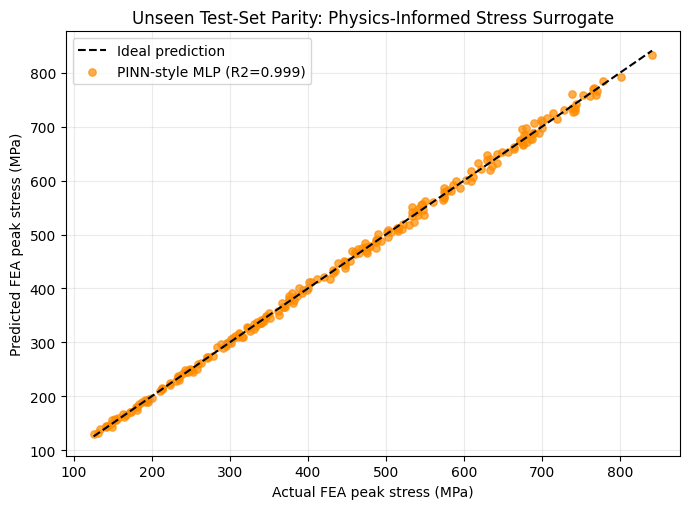

,model,R2,RMSE_MPa,MAE_MPa
0,Physics-informed MLP,0.998726,6.632049,5.189505


In [13]:
# Physics-informed neural-network surrogate adapted to the project's actual CSV schema.
# No radial observations are available, so the physics term is a hole-edge
# consistency penalty against the analytical finite-width reference.

pinn_seed = 42
np.random.seed(pinn_seed)
torch.manual_seed(pinn_seed)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

pinn_split_paths = {
    "train": Path("train_fea_stress.csv"),
    "validation": Path("val_fea_stress.csv"),
    "test": Path("test_fea_stress.csv"),
}
pinn_split_frames = {
    split_name: pd.read_csv(split_path)
    for split_name, split_path in pinn_split_paths.items()
}

pinn_required_columns = [
    "sample_id",
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "finite_width_Kt",
    "fea_peak_stress_MPa",
    "d_over_w_ratio",
]
for split_name, split_frame in pinn_split_frames.items():
    missing_columns = [
        column for column in pinn_required_columns if column not in split_frame.columns
    ]
    assert not missing_columns, f"{split_name} split is missing columns: {missing_columns}"
    assert split_frame[pinn_required_columns].notna().all().all(), (
        f"{split_name} split contains missing required values."
    )
    assert (split_frame[["width_mm", "hole_diameter_mm", "thickness_mm"]] > 0).all().all()
    assert (split_frame["width_mm"] > split_frame["hole_diameter_mm"]).all()
    calculated_d_over_w = split_frame["hole_diameter_mm"] / split_frame["width_mm"]
    assert np.allclose(
        split_frame["d_over_w_ratio"], calculated_d_over_w, rtol=0, atol=1e-12
    ), f"d_over_w_ratio validation failed for {split_name}."
    assert split_frame["d_over_w_ratio"].between(0.05, 0.35).all()

pinn_sample_id_sets = {
    split_name: set(split_frame["sample_id"])
    for split_name, split_frame in pinn_split_frames.items()
}
assert pinn_sample_id_sets["train"].isdisjoint(pinn_sample_id_sets["validation"])
assert pinn_sample_id_sets["train"].isdisjoint(pinn_sample_id_sets["test"])
assert pinn_sample_id_sets["validation"].isdisjoint(pinn_sample_id_sets["test"])
assert sum(len(sample_ids) for sample_ids in pinn_sample_id_sets.values()) == len(
    set().union(*pinn_sample_id_sets.values())
)

# Schema adaptation and physics quantities. The engineered force is retained
# for the net-section calculation, but is deliberately not a model input.
def adapt_pinn_frame(source_frame):
    adapted_frame = source_frame.copy()
    adapted_frame["plate_width_mm"] = adapted_frame["width_mm"]
    adapted_frame["hole_radius_mm"] = adapted_frame["hole_diameter_mm"] / 2.0
    adapted_frame["plate_thickness_mm"] = adapted_frame["thickness_mm"]
    adapted_frame["tensile_force_kn"] = (
        adapted_frame["nominal_stress_MPa"]
        * adapted_frame["width_mm"]
        * adapted_frame["thickness_mm"]
        / 1000.0
    )
    adapted_frame["sigma_inf_calc"] = adapted_frame["nominal_stress_MPa"]
    net_section_area_mm2 = (
        adapted_frame["width_mm"] - adapted_frame["hole_diameter_mm"]
    ) * adapted_frame["thickness_mm"]
    adapted_frame["sigma_net_calc"] = (
        adapted_frame["tensile_force_kn"] * 1000.0 / net_section_area_mm2
    )
    adapted_frame["analytical_hole_edge_reference_MPa"] = (
        adapted_frame["finite_width_Kt"] * adapted_frame["sigma_inf_calc"]
    )
    return adapted_frame

pinn_adapted_frames = {
    split_name: adapt_pinn_frame(split_frame)
    for split_name, split_frame in pinn_split_frames.items()
}

pinn_input_columns = [
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "d_over_w_ratio",
    "nominal_stress_MPa",
    "sigma_inf_calc",
    "sigma_net_calc",
]
pinn_target_column = "fea_peak_stress_MPa"
pinn_physics_column = "analytical_hole_edge_reference_MPa"

for split_name, split_frame in pinn_adapted_frames.items():
    assert split_frame[pinn_input_columns + [pinn_target_column, pinn_physics_column]].notna().all().all(), (
        f"{split_name} split contains missing PINN values."
    )
    expected_sigma_net = (
        split_frame["sigma_inf_calc"]
        * split_frame["width_mm"]
        / (split_frame["width_mm"] - split_frame["hole_diameter_mm"])
    )
    assert np.allclose(split_frame["sigma_net_calc"], expected_sigma_net, rtol=0, atol=1e-10)
    assert np.allclose(
        split_frame[pinn_physics_column],
        split_frame["finite_width_Kt"] * split_frame["sigma_inf_calc"],
        rtol=0,
        atol=1e-10,
    )

pinn_train_frame = pinn_adapted_frames["train"]
pinn_validation_frame = pinn_adapted_frames["validation"]
pinn_test_frame = pinn_adapted_frames["test"]

# Fit every scaler on train only; the analytical reference uses the train-fitted
# target scaler so the two terms are comparable in the training objective.
pinn_input_scaler = StandardScaler().fit(pinn_train_frame[pinn_input_columns])
pinn_target_scaler = StandardScaler().fit(
    pinn_train_frame[[pinn_target_column]]
)

def pinn_arrays(frame):
    inputs = pinn_input_scaler.transform(frame[pinn_input_columns]).astype(np.float32)
    targets = pinn_target_scaler.transform(frame[[pinn_target_column]]).astype(np.float32)
    physics_reference = pinn_target_scaler.transform(
        frame[[pinn_physics_column]].rename(columns={pinn_physics_column: pinn_target_column})
    ).astype(np.float32)
    return inputs, targets, physics_reference

pinn_X_train, pinn_y_train, pinn_ref_train = pinn_arrays(pinn_train_frame)
pinn_X_validation, pinn_y_validation, pinn_ref_validation = pinn_arrays(
    pinn_validation_frame
)
pinn_X_test, pinn_y_test, pinn_ref_test = pinn_arrays(pinn_test_frame)

class PhysicsInformedStressMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, inputs):
        return self.network(inputs)

pinn_model = PhysicsInformedStressMLP(len(pinn_input_columns))
pinn_optimizer = torch.optim.Adam(
    pinn_model.parameters(), lr=1e-3, weight_decay=1e-5
)
pinn_loss_function = nn.MSELoss()
pinn_physics_weight = 0.20
pinn_max_epochs = 1400
pinn_patience = 120

pinn_X_train_tensor = torch.from_numpy(pinn_X_train)
pinn_y_train_tensor = torch.from_numpy(pinn_y_train)
pinn_ref_train_tensor = torch.from_numpy(pinn_ref_train)
pinn_X_validation_tensor = torch.from_numpy(pinn_X_validation)
pinn_y_validation_tensor = torch.from_numpy(pinn_y_validation)
pinn_ref_validation_tensor = torch.from_numpy(pinn_ref_validation)

pinn_best_state = None
pinn_best_validation_loss = float("inf")
pinn_wait = 0
for pinn_epoch in range(pinn_max_epochs):
    pinn_model.train()
    pinn_optimizer.zero_grad(set_to_none=True)
    pinn_train_prediction = pinn_model(pinn_X_train_tensor)
    pinn_supervised_loss = pinn_loss_function(pinn_train_prediction, pinn_y_train_tensor)
    pinn_hole_edge_physics_loss = pinn_loss_function(
        pinn_train_prediction, pinn_ref_train_tensor
    )
    pinn_total_loss = pinn_supervised_loss + pinn_physics_weight * pinn_hole_edge_physics_loss
    pinn_total_loss.backward()
    pinn_optimizer.step()

    pinn_model.eval()
    with torch.no_grad():
        pinn_validation_prediction = pinn_model(pinn_X_validation_tensor)
        pinn_validation_supervised_loss = pinn_loss_function(
            pinn_validation_prediction, pinn_y_validation_tensor
        )
        pinn_validation_physics_loss = pinn_loss_function(
            pinn_validation_prediction, pinn_ref_validation_tensor
        )
        pinn_validation_total_loss = (
            pinn_validation_supervised_loss
            + pinn_physics_weight * pinn_validation_physics_loss
        ).item()

    if pinn_validation_total_loss < pinn_best_validation_loss - 1e-9:
        pinn_best_validation_loss = pinn_validation_total_loss
        pinn_best_state = {
            name: parameter.detach().clone()
            for name, parameter in pinn_model.state_dict().items()
        }
        pinn_best_epoch = pinn_epoch + 1
        pinn_wait = 0
    else:
        pinn_wait += 1
        if pinn_wait >= pinn_patience:
            break

assert pinn_best_state is not None
pinn_model.load_state_dict(pinn_best_state)
pinn_model.eval()
with torch.no_grad():
    pinn_test_scaled_predictions = pinn_model(torch.from_numpy(pinn_X_test)).cpu().numpy()

pinn_test_predictions = pinn_target_scaler.inverse_transform(
    pinn_test_scaled_predictions
).ravel()
pinn_y_test_raw = pinn_test_frame[pinn_target_column].to_numpy(dtype=np.float32)
pinn_test_reference_raw = pinn_test_frame[pinn_physics_column].to_numpy(dtype=np.float32)

pinn_metrics = {
    "R2": r2_score(pinn_y_test_raw, pinn_test_predictions),
    "RMSE_MPa": np.sqrt(mean_squared_error(pinn_y_test_raw, pinn_test_predictions)),
    "MAE_MPa": mean_absolute_error(pinn_y_test_raw, pinn_test_predictions),
}
pinn_benchmark_table = pd.DataFrame([{"model": "Physics-informed MLP", **pinn_metrics}])

print("PINN schema adaptation")
print("Available-to-workflow mappings: width_mm -> plate width; hole_diameter_mm / 2 -> hole radius; thickness_mm -> plate thickness")
print("Derived tensile_force_kn = nominal_stress_MPa * width_mm * thickness_mm / 1000")
print("sigma_inf_calc = nominal_stress_MPa; sigma_net_calc = force / net-section area")
print("Physics replacement: hole-edge penalty against finite_width_Kt * sigma_inf_calc; no radial/asymptote observations were fabricated.")
print(f"Leakage-safe model inputs ({len(pinn_input_columns)}): {pinn_input_columns}")
print(f"Target: {pinn_target_column}")
print(
    "Split sizes and disjointness: "
    + ", ".join(f"{name}={len(frame)}" for name, frame in pinn_split_frames.items())
    + " | PASS"
)
print(
    f"Best validation epoch: {pinn_best_epoch} "
    f"(combined validation loss={pinn_best_validation_loss:.6f}; physics weight={pinn_physics_weight:.2f})"
)
print("Unseen test-set PINN metrics (higher R2 and lower RMSE/MAE are better):")
print(
    pinn_benchmark_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAE_MPa": "{:.4f}".format,
        },
    )
)

pinn_parity_min = min(pinn_y_test_raw.min(), pinn_test_predictions.min())
pinn_parity_max = max(pinn_y_test_raw.max(), pinn_test_predictions.max())
plt.figure(figsize=(7, 5.2))
plt.plot(
    [pinn_parity_min, pinn_parity_max],
    [pinn_parity_min, pinn_parity_max],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Ideal prediction",
)
plt.scatter(
    pinn_y_test_raw,
    pinn_test_predictions,
    s=28,
    alpha=0.70,
    color="darkorange",
    label=f"PINN-style MLP (R2={pinn_metrics['R2']:.3f})",
)
plt.xlabel("Actual FEA peak stress (MPa)")
plt.ylabel("Predicted FEA peak stress (MPa)")
plt.title("Unseen Test-Set Parity: Physics-Informed Stress Surrogate")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

pinn_benchmark_table

## Multi\-Scale Input and Target Normalization PINN

Multi-scale PINN schema adaptation
Source splits: train=1050, validation=220, test=230
Derived quantities: hole_radius_mm, tensile_force_kn, sigma_inf_calc, sigma_net_calc, target_hole_edge_stress
Feature construction: 12 physically defined non-radial features
Features: ['width_mm', 'hole_diameter_mm', 'thickness_mm', 'nominal_stress_MPa', 'd_over_w_ratio', 'finite_width_Kt', 'hole_radius_mm', 'tensile_force_kn', 'sigma_inf_calc', 'sigma_net_calc', 'net_section_width_mm', 'net_section_area_mm2']
No radial/evaluation coordinate was constructed: no radial observations exist. The physics term is finite-width analytical consistency.
Leakage control: feature and target StandardScaler objects were fitted on train only; the physics reference uses the train-fitted target scaler.
Training device: cpu | seed=42 | best epoch=1600
Best combined validation loss: 0.002048 | physics weight=0.20
Unseen test-set results (MPa; higher R2 and lower RMSE/MAE are better):
                            model  

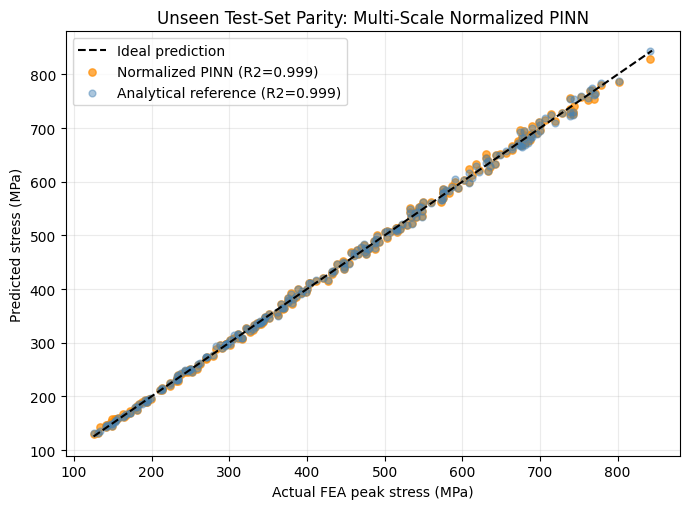

,model,R2,RMSE_MPa,MAE_MPa,comparison
0,Multi-scale normalized PINN,0.998622,6.896470,5.318362,supervised + finite-width physics penalty
1,Finite-width analytical reference,0.998730,6.620558,5.157379,physics-only reference


In [21]:
# Multi-scale input normalization and target normalization PINN adapted to the project CSV schema.
# Source columns are read only from the exported project splits; all other quantities below
# are physically derived within the workflow.
ms_seed = 42
np.random.seed(ms_seed)
torch.manual_seed(ms_seed)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
ms_device = torch.device("cpu")

ms_split_paths = {
    "train": Path("train_fea_stress.csv"),
    "validation": Path("val_fea_stress.csv"),
    "test": Path("test_fea_stress.csv"),
}
ms_source_required_columns = [
    "sample_id",
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "d_over_w_ratio",
    "finite_width_Kt",
    "fea_peak_stress_MPa",
]
ms_raw_frames = {
    split_name: pd.read_csv(split_path)
    for split_name, split_path in ms_split_paths.items()
}

for ms_split_name, ms_raw_frame in ms_raw_frames.items():
    ms_missing_columns = [
        column for column in ms_source_required_columns
        if column not in ms_raw_frame.columns
    ]
    assert not ms_missing_columns, (
        f"{ms_split_name} split is missing source columns: {ms_missing_columns}"
    )
    assert ms_raw_frame[ms_source_required_columns].notna().all().all(), (
        f"{ms_split_name} split contains missing source values."
    )


def ms_add_derived_physics(ms_source_frame):
    """Add physically defined quantities without fabricating radial observations."""
    ms_frame = ms_source_frame.copy()
    ms_frame["hole_radius_mm"] = ms_frame["hole_diameter_mm"] / 2.0
    ms_frame["tensile_force_kn"] = (
        ms_frame["nominal_stress_MPa"]
        * ms_frame["width_mm"]
        * ms_frame["thickness_mm"]
        / 1000.0
    )
    ms_frame["sigma_inf_calc"] = ms_frame["nominal_stress_MPa"]
    ms_frame["net_section_width_mm"] = (
        ms_frame["width_mm"] - ms_frame["hole_diameter_mm"]
    )
    ms_frame["net_section_area_mm2"] = (
        ms_frame["net_section_width_mm"] * ms_frame["thickness_mm"]
    )
    ms_frame["sigma_net_calc"] = (
        ms_frame["tensile_force_kn"] * 1000.0 / ms_frame["net_section_area_mm2"]
    )
    ms_frame["target_hole_edge_stress"] = (
        ms_frame["finite_width_Kt"] * ms_frame["sigma_inf_calc"]
    )
    return ms_frame


ms_frames = {
    split_name: ms_add_derived_physics(ms_raw_frame)
    for split_name, ms_raw_frame in ms_raw_frames.items()
}

for ms_split_name, ms_frame in ms_frames.items():
    ms_calculated_ratio = ms_frame["hole_diameter_mm"] / ms_frame["width_mm"]
    assert np.allclose(
        ms_frame["d_over_w_ratio"], ms_calculated_ratio, rtol=0, atol=1e-12
    ), f"d_over_w_ratio validation failed for {ms_split_name}."
    assert ms_frame["d_over_w_ratio"].between(0.05, 0.35).all()
    assert (ms_frame[["width_mm", "hole_diameter_mm", "thickness_mm"]] > 0).all().all()
    assert (ms_frame["net_section_width_mm"] > 0).all()
    assert (ms_frame["net_section_area_mm2"] > 0).all()
    assert ms_frame[
        [
            "hole_radius_mm",
            "tensile_force_kn",
            "sigma_inf_calc",
            "sigma_net_calc",
            "target_hole_edge_stress",
        ]
    ].notna().all().all()
    assert np.allclose(
        ms_frame["sigma_net_calc"],
        ms_frame["sigma_inf_calc"]
        * ms_frame["width_mm"]
        / ms_frame["net_section_width_mm"],
        rtol=0,
        atol=1e-10,
    )
    assert np.allclose(
        ms_frame["target_hole_edge_stress"],
        ms_frame["finite_width_Kt"] * ms_frame["sigma_inf_calc"],
        rtol=0,
        atol=1e-10,
    )

ms_sample_id_sets = {
    split_name: set(ms_frame["sample_id"])
    for split_name, ms_frame in ms_frames.items()
}
assert ms_sample_id_sets["train"].isdisjoint(ms_sample_id_sets["validation"])
assert ms_sample_id_sets["train"].isdisjoint(ms_sample_id_sets["test"])
assert ms_sample_id_sets["validation"].isdisjoint(ms_sample_id_sets["test"])

# The files contain no radial measurements or evaluation coordinates. Thus, no radial
# feature or far-field asymptote term is fabricated; the physics term is analytical
# finite-width hole-edge consistency instead.
ms_radial_feature_status = (
    "No radial/evaluation coordinate was constructed: no radial observations exist. "
    "The physics term is finite-width analytical consistency."
)
ms_feature_columns = [
    "width_mm",
    "hole_diameter_mm",
    "thickness_mm",
    "nominal_stress_MPa",
    "d_over_w_ratio",
    "finite_width_Kt",
    "hole_radius_mm",
    "tensile_force_kn",
    "sigma_inf_calc",
    "sigma_net_calc",
    "net_section_width_mm",
    "net_section_area_mm2",
]
ms_target_column = "fea_peak_stress_MPa"
ms_physics_column = "target_hole_edge_stress"
assert len(ms_feature_columns) == 12

ms_train_frame = ms_frames["train"]
ms_validation_frame = ms_frames["validation"]
ms_test_frame = ms_frames["test"]

# Both scalers are fitted on train only. The physics reference is transformed with
# the same train-fitted target scaler as the supervised target.
ms_feature_scaler = StandardScaler().fit(ms_train_frame[ms_feature_columns])
ms_target_scaler = StandardScaler().fit(ms_train_frame[[ms_target_column]])


def ms_scaled_arrays(ms_frame):
    ms_inputs = ms_feature_scaler.transform(
        ms_frame[ms_feature_columns]
    ).astype(np.float32)
    ms_targets = ms_target_scaler.transform(
        ms_frame[[ms_target_column]]
    ).astype(np.float32)
    ms_reference_for_scaler = ms_frame[[ms_physics_column]].rename(
        columns={ms_physics_column: ms_target_column}
    )
    ms_physics_reference = ms_target_scaler.transform(
        ms_reference_for_scaler
    ).astype(np.float32)
    return ms_inputs, ms_targets, ms_physics_reference


ms_X_train, ms_y_train, ms_ref_train = ms_scaled_arrays(ms_train_frame)
ms_X_validation, ms_y_validation, ms_ref_validation = ms_scaled_arrays(
    ms_validation_frame
)
ms_X_test, ms_y_test, ms_ref_test = ms_scaled_arrays(ms_test_frame)


class MultiScaleNormalizedPINN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, inputs):
        return self.network(inputs)


# Deterministic full-batch CPU training with validation-based early stopping.
torch.manual_seed(ms_seed)
ms_model = MultiScaleNormalizedPINN(len(ms_feature_columns)).to(ms_device)
ms_optimizer = torch.optim.Adam(
    ms_model.parameters(), lr=1e-3, weight_decay=1e-5
)
ms_loss_function = nn.MSELoss()
ms_physics_weight = 0.20
ms_max_epochs = 1600
ms_patience = 120

ms_X_train_tensor = torch.from_numpy(ms_X_train).to(ms_device)
ms_y_train_tensor = torch.from_numpy(ms_y_train).to(ms_device)
ms_ref_train_tensor = torch.from_numpy(ms_ref_train).to(ms_device)
ms_X_validation_tensor = torch.from_numpy(ms_X_validation).to(ms_device)
ms_y_validation_tensor = torch.from_numpy(ms_y_validation).to(ms_device)
ms_ref_validation_tensor = torch.from_numpy(ms_ref_validation).to(ms_device)
ms_X_test_tensor = torch.from_numpy(ms_X_test).to(ms_device)

ms_best_state = None
ms_best_validation_loss = float("inf")
ms_best_epoch = 0
ms_wait = 0
for ms_epoch in range(ms_max_epochs):
    ms_model.train()
    ms_optimizer.zero_grad(set_to_none=True)
    ms_train_prediction = ms_model(ms_X_train_tensor)
    ms_supervised_loss = ms_loss_function(ms_train_prediction, ms_y_train_tensor)
    ms_physics_loss = ms_loss_function(ms_train_prediction, ms_ref_train_tensor)
    ms_total_loss = ms_supervised_loss + ms_physics_weight * ms_physics_loss
    ms_total_loss.backward()
    ms_optimizer.step()

    ms_model.eval()
    with torch.no_grad():
        ms_validation_prediction = ms_model(ms_X_validation_tensor)
        ms_validation_supervised_loss = ms_loss_function(
            ms_validation_prediction, ms_y_validation_tensor
        )
        ms_validation_physics_loss = ms_loss_function(
            ms_validation_prediction, ms_ref_validation_tensor
        )
        ms_validation_total_loss = (
            ms_validation_supervised_loss
            + ms_physics_weight * ms_validation_physics_loss
        ).item()

    if ms_validation_total_loss < ms_best_validation_loss - 1e-9:
        ms_best_validation_loss = ms_validation_total_loss
        ms_best_state = {
            name: parameter.detach().clone()
            for name, parameter in ms_model.state_dict().items()
        }
        ms_best_epoch = ms_epoch + 1
        ms_wait = 0
    else:
        ms_wait += 1
        if ms_wait >= ms_patience:
            break

assert ms_best_state is not None
ms_model.load_state_dict(ms_best_state)
ms_model.eval()
with torch.no_grad():
    ms_test_scaled_predictions = ms_model(ms_X_test_tensor).cpu().numpy()

ms_test_predictions = ms_target_scaler.inverse_transform(
    ms_test_scaled_predictions
).ravel()
ms_test_actual = ms_test_frame[ms_target_column].to_numpy(dtype=np.float64)
ms_test_reference = ms_test_frame[ms_physics_column].to_numpy(dtype=np.float64)


def ms_regression_metrics(ms_actual, ms_predictions):
    return {
        "R2": r2_score(ms_actual, ms_predictions),
        "RMSE_MPa": np.sqrt(mean_squared_error(ms_actual, ms_predictions)),
        "MAE_MPa": mean_absolute_error(ms_actual, ms_predictions),
    }


ms_pinn_metrics = ms_regression_metrics(ms_test_actual, ms_test_predictions)
ms_reference_metrics = ms_regression_metrics(ms_test_actual, ms_test_reference)
ms_benchmark_table = pd.DataFrame(
    [
        {
            "model": "Multi-scale normalized PINN",
            **ms_pinn_metrics,
            "comparison": "supervised + finite-width physics penalty",
        },
        {
            "model": "Finite-width analytical reference",
            **ms_reference_metrics,
            "comparison": "physics-only reference",
        },
    ]
)[["model", "R2", "RMSE_MPa", "MAE_MPa", "comparison"]]

print("Multi-scale PINN schema adaptation")
print(
    f"Source splits: train={len(ms_train_frame)}, "
    f"validation={len(ms_validation_frame)}, test={len(ms_test_frame)}"
)
print(
    "Derived quantities: hole_radius_mm, tensile_force_kn, sigma_inf_calc, "
    "sigma_net_calc, target_hole_edge_stress"
)
print(
    f"Feature construction: {len(ms_feature_columns)} physically defined "
    "non-radial features"
)
print(f"Features: {ms_feature_columns}")
print(ms_radial_feature_status)
print(
    "Leakage control: feature and target StandardScaler objects were fitted on "
    "train only; the physics reference uses the train-fitted target scaler."
)
print(f"Training device: {ms_device} | seed={ms_seed} | best epoch={ms_best_epoch}")
print(
    f"Best combined validation loss: {ms_best_validation_loss:.6f} | "
    f"physics weight={ms_physics_weight:.2f}"
)
print("Unseen test-set results (MPa; higher R2 and lower RMSE/MAE are better):")
print(
    ms_benchmark_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAE_MPa": "{:.4f}".format,
        },
    )
)

ms_parity_min = min(
    ms_test_actual.min(), ms_test_predictions.min(), ms_test_reference.min()
)
ms_parity_max = max(
    ms_test_actual.max(), ms_test_predictions.max(), ms_test_reference.max()
)
ms_parity_figure, ms_parity_axis = plt.subplots(figsize=(7, 5.2))
ms_parity_axis.plot(
    [ms_parity_min, ms_parity_max],
    [ms_parity_min, ms_parity_max],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Ideal prediction",
)
ms_parity_axis.scatter(
    ms_test_actual,
    ms_test_predictions,
    s=28,
    alpha=0.70,
    color="darkorange",
    label=f"Normalized PINN (R2={ms_pinn_metrics['R2']:.3f})",
)
ms_parity_axis.scatter(
    ms_test_actual,
    ms_test_reference,
    s=24,
    alpha=0.45,
    color="steelblue",
    label=f"Analytical reference (R2={ms_reference_metrics['R2']:.3f})",
)
ms_parity_axis.set_xlabel("Actual FEA peak stress (MPa)")
ms_parity_axis.set_ylabel("Predicted stress (MPa)")
ms_parity_axis.set_title("Unseen Test-Set Parity: Multi-Scale Normalized PINN")
ms_parity_axis.grid(alpha=0.25)
ms_parity_axis.legend()
ms_parity_figure.tight_layout()
plt.show()

ms_benchmark_table

Spatial visualization note: the trained \`ms\_model\` predicts one sample\-level \`fea\_peak\_stress\_MPa\` value from the 12 physically defined features; it does not infer a radial or dense spatial stress field\. This project contains no Young’s modulus, Poisson ratio, radial\-coordinate, or spatial stress observations, so the visualization below uses the model only for a scalar surrogate edge peak and overlays a clearly labeled analytical Kirsch plane\-stress field scaled to that peak\.

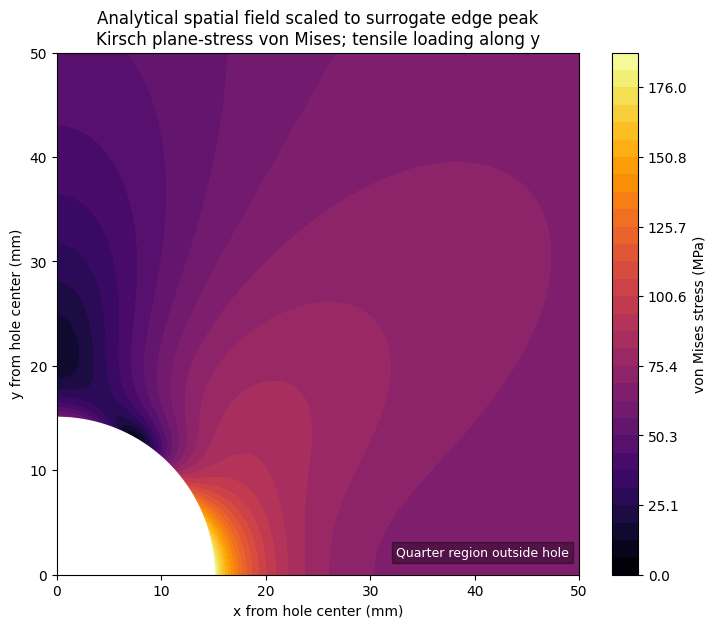

Representative case: W=100 mm, hole radius=15 mm, thickness=5 mm, load=40 kN
Nominal stress derived from F/(W*t): 80.0000 MPa
Surrogate edge prediction: 188.5330 MPa
Finite-width analytical reference: 187.7441 MPa
Max contour value: 188.5330 MPa
Visualization label: analytical spatial field scaled to surrogate edge peak


In [23]:
# Physically honest spatial visualization: scalar surrogate edge prediction plus
# an analytical Kirsch plane-stress field scaled to that scalar prediction.

vis_case_width_mm = 100.0
vis_case_hole_radius_mm = 15.0
vis_case_hole_diameter_mm = 2.0 * vis_case_hole_radius_mm
vis_case_thickness_mm = 5.0
vis_case_load_kn = 40.0
vis_case_force_n = vis_case_load_kn * 1000.0
vis_case_nominal_stress_mpa = (
    vis_case_force_n / (vis_case_width_mm * vis_case_thickness_mm)
)
vis_case_d_over_w_ratio = vis_case_hole_diameter_mm / vis_case_width_mm
vis_case_finite_width_kt = (
    3.0
    - 3.14 * vis_case_d_over_w_ratio
    + 3.667 * vis_case_d_over_w_ratio**2
    - 1.527 * vis_case_d_over_w_ratio**3
)
vis_case_tensile_force_kn = (
    vis_case_nominal_stress_mpa
    * vis_case_width_mm
    * vis_case_thickness_mm
    / 1000.0
)
vis_case_sigma_inf_calc = vis_case_nominal_stress_mpa
vis_case_net_section_width_mm = (
    vis_case_width_mm - vis_case_hole_diameter_mm
)
vis_case_net_section_area_mm2 = (
    vis_case_net_section_width_mm * vis_case_thickness_mm
)
vis_case_sigma_net_calc = (
    vis_case_tensile_force_kn * 1000.0 / vis_case_net_section_area_mm2
)

# Build the model input in the exact feature order used during training.
vis_case_feature_row = pd.DataFrame(
    [[
        vis_case_width_mm,
        vis_case_hole_diameter_mm,
        vis_case_thickness_mm,
        vis_case_nominal_stress_mpa,
        vis_case_d_over_w_ratio,
        vis_case_finite_width_kt,
        vis_case_hole_radius_mm,
        vis_case_tensile_force_kn,
        vis_case_sigma_inf_calc,
        vis_case_sigma_net_calc,
        vis_case_net_section_width_mm,
        vis_case_net_section_area_mm2,
    ]],
    columns=ms_feature_columns,
)
assert list(vis_case_feature_row.columns) == list(ms_feature_columns)

vis_scaled_model_input = ms_feature_scaler.transform(
    vis_case_feature_row[ms_feature_columns]
).astype(np.float32)
vis_model_input_tensor = torch.from_numpy(vis_scaled_model_input)
vis_model_was_training = ms_model.training
ms_model.eval()
with torch.no_grad():
    vis_scaled_edge_prediction = ms_model(vis_model_input_tensor).cpu().numpy()
if vis_model_was_training:
    ms_model.train()
else:
    ms_model.eval()
vis_surrogate_edge_prediction_mpa = float(
    ms_target_scaler.inverse_transform(vis_scaled_edge_prediction).ravel()[0]
)
vis_finite_width_analytical_reference_mpa = (
    vis_case_finite_width_kt * vis_case_sigma_inf_calc
)


def vis_kirsch_y_tension_plane_stress_vm(
    remote_stress_mpa, hole_radius_mm, radial_mm, theta_rad
):
    """Kirsch plane-stress von Mises field for remote tension along the y axis."""
    safe_radial_mm = np.where(radial_mm >= hole_radius_mm, radial_mm, np.nan)
    radius_ratio_squared = (hole_radius_mm / safe_radial_mm) ** 2
    cos_two_theta = np.cos(2.0 * theta_rad)
    sin_two_theta = np.sin(2.0 * theta_rad)

    # These polar stresses are the y-loading rotation of the standard Kirsch solution.
    sigma_rr = (
        0.5 * remote_stress_mpa * (1.0 - radius_ratio_squared)
        - 0.5
        * remote_stress_mpa
        * (1.0 - 4.0 * radius_ratio_squared + 3.0 * radius_ratio_squared**2)
        * cos_two_theta
    )
    sigma_theta_theta = (
        0.5 * remote_stress_mpa * (1.0 + radius_ratio_squared)
        + 0.5
        * remote_stress_mpa
        * (1.0 + 3.0 * radius_ratio_squared**2)
        * cos_two_theta
    )
    tau_r_theta = (
        0.5
        * remote_stress_mpa
        * (1.0 + 2.0 * radius_ratio_squared - 3.0 * radius_ratio_squared**2)
        * sin_two_theta
    )

    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)
    sigma_xx = (
        sigma_rr * cos_theta**2
        + sigma_theta_theta * sin_theta**2
        - 2.0 * tau_r_theta * sin_theta * cos_theta
    )
    sigma_yy = (
        sigma_rr * sin_theta**2
        + sigma_theta_theta * cos_theta**2
        + 2.0 * tau_r_theta * sin_theta * cos_theta
    )
    sigma_xy = (
        (sigma_rr - sigma_theta_theta) * sin_theta * cos_theta
        + tau_r_theta * (cos_theta**2 - sin_theta**2)
    )
    von_mises_mpa = np.sqrt(
        np.maximum(
            0.0,
            sigma_xx**2 - sigma_xx * sigma_yy + sigma_yy**2 + 3.0 * sigma_xy**2,
        )
    )
    return von_mises_mpa


# Evaluate the quarter plate region x >= 0, y >= 0 outside the circular hole.
vis_grid_points = 401
vis_quarter_extent_mm = vis_case_width_mm / 2.0
vis_grid_x_mm = np.linspace(0.0, vis_quarter_extent_mm, vis_grid_points)
vis_grid_y_mm = np.linspace(0.0, vis_quarter_extent_mm, vis_grid_points)
vis_grid_xx_mm, vis_grid_yy_mm = np.meshgrid(vis_grid_x_mm, vis_grid_y_mm)
vis_grid_radial_mm = np.hypot(vis_grid_xx_mm, vis_grid_yy_mm)
vis_grid_theta_rad = np.arctan2(vis_grid_yy_mm, vis_grid_xx_mm)
vis_raw_kirsch_vm_field_mpa = vis_kirsch_y_tension_plane_stress_vm(
    vis_case_sigma_inf_calc,
    vis_case_hole_radius_mm,
    vis_grid_radial_mm,
    vis_grid_theta_rad,
)

# Use the exact hole-edge arc to define the normalization target.
vis_edge_theta_rad = np.linspace(0.0, np.pi / 2.0, 721)
vis_edge_radial_mm = np.full_like(vis_edge_theta_rad, vis_case_hole_radius_mm)
vis_raw_kirsch_edge_vm_mpa = vis_kirsch_y_tension_plane_stress_vm(
    vis_case_sigma_inf_calc,
    vis_case_hole_radius_mm,
    vis_edge_radial_mm,
    vis_edge_theta_rad,
)
vis_raw_kirsch_edge_max_mpa = float(np.nanmax(vis_raw_kirsch_edge_vm_mpa))
vis_field_scale_to_surrogate = (
    vis_surrogate_edge_prediction_mpa / vis_raw_kirsch_edge_max_mpa
)
vis_scaled_kirsch_vm_field_mpa = (
    vis_raw_kirsch_vm_field_mpa * vis_field_scale_to_surrogate
)
vis_scaled_field_max_contour_mpa = float(np.nanmax(vis_scaled_kirsch_vm_field_mpa))

vis_field_label = "analytical spatial field scaled to surrogate edge peak"
vis_plot_figure, vis_plot_axis = plt.subplots(figsize=(7.4, 6.2))
vis_contour_levels = np.linspace(0.0, vis_scaled_field_max_contour_mpa, 31)
vis_contour = vis_plot_axis.contourf(
    vis_grid_xx_mm,
    vis_grid_yy_mm,
    np.ma.masked_invalid(vis_scaled_kirsch_vm_field_mpa),
    levels=vis_contour_levels,
    cmap="inferno",
)
vis_plot_figure.colorbar(
    vis_contour,
    ax=vis_plot_axis,
    label="von Mises stress (MPa)",
)
vis_hole_boundary_theta = np.linspace(0.0, np.pi / 2.0, 300)
vis_plot_axis.plot(
    vis_case_hole_radius_mm * np.cos(vis_hole_boundary_theta),
    vis_case_hole_radius_mm * np.sin(vis_hole_boundary_theta),
    color="white",
    linewidth=2.0,
)
vis_plot_axis.set_aspect("equal")
vis_plot_axis.set_xlim(0.0, vis_quarter_extent_mm)
vis_plot_axis.set_ylim(0.0, vis_quarter_extent_mm)
vis_plot_axis.set_xlabel("x from hole center (mm)")
vis_plot_axis.set_ylabel("y from hole center (mm)")
vis_plot_axis.set_title(
    "Analytical spatial field scaled to surrogate edge peak\n"
    "Kirsch plane-stress von Mises; tensile loading along y"
)
vis_plot_axis.text(
    0.98,
    0.03,
    "Quarter region outside hole",
    transform=vis_plot_axis.transAxes,
    ha="right",
    va="bottom",
    color="white",
    fontsize=9,
    bbox={"facecolor": "black", "alpha": 0.35, "pad": 3},
)
vis_plot_figure.tight_layout()
plt.show()

print("Representative case: W=100 mm, hole radius=15 mm, thickness=5 mm, load=40 kN")
print(f"Nominal stress derived from F/(W*t): {vis_case_nominal_stress_mpa:.4f} MPa")
print(f"Surrogate edge prediction: {vis_surrogate_edge_prediction_mpa:.4f} MPa")
print(
    "Finite-width analytical reference: "
    f"{vis_finite_width_analytical_reference_mpa:.4f} MPa"
)
print(f"Max contour value: {vis_scaled_field_max_contour_mpa:.4f} MPa")
print(f"Visualization label: {vis_field_label}")

## Module: Physics\-Fidelity & Critical Boundary Evaluation

Module: Physics-Fidelity & Critical Boundary Evaluation
Test samples evaluated: 230
Target: fea_peak_stress_MPa
Analytical reference: finite_width_Kt * nominal_stress_MPa

Global test-set metrics; surrogate and analytical reference are compared with the FEA target:
                            model       R2 MAE_MPa RMSE_MPa MAPE_pct
       Multi-scale PINN surrogate 0.998622  5.3184   6.8965   1.2733
Analytical finite-width reference 0.998730  5.1574   6.6206   1.1945

All-sample analytical-reference comparison over sample-level edge peaks:
                        comparison  sample_count mean_absolute_percentage_deviation_pct median_absolute_percentage_deviation_pct
Analytical reference vs FEA target           230                                 1.1945                                   1.0019
 Surrogate vs analytical reference           230                                 0.4495                                   0.2604
Critical-zone metrics for x/r <= 1.15: UNAVAILABLE. The project sc

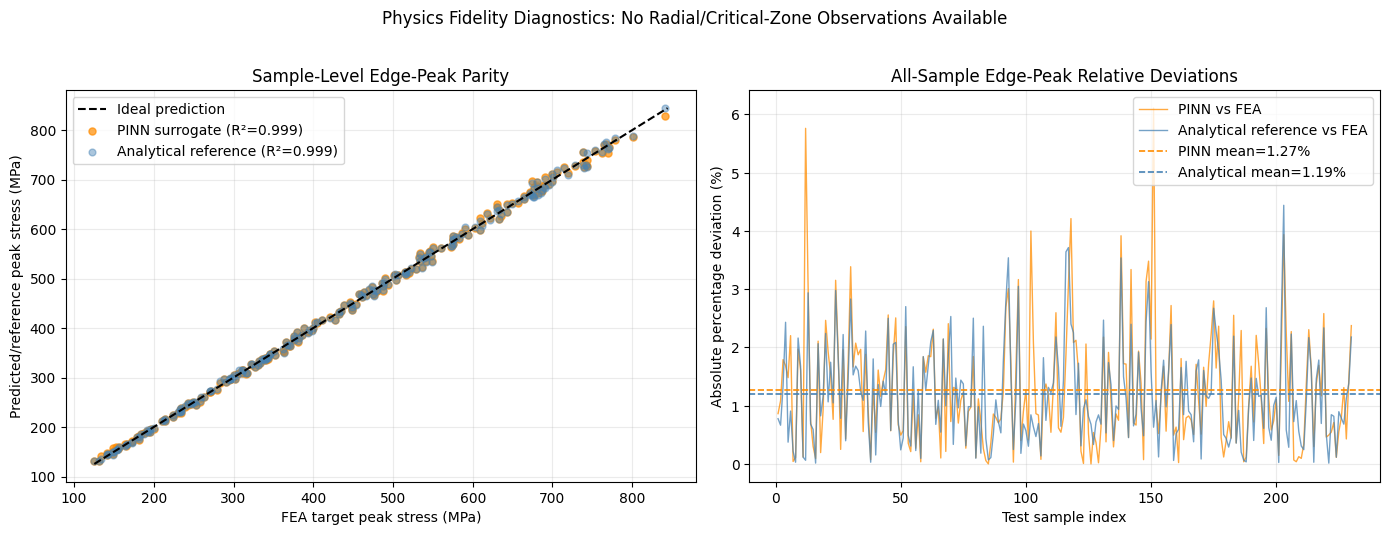

,model,R2,MAE_MPa,RMSE_MPa,MAPE_pct
0,Multi-scale PINN surrogate,0.998622,5.318362,6.896470,1.273290
1,Analytical finite-width reference,0.998730,5.157379,6.620558,1.194451


In [25]:
# Module: Physics-Fidelity & Critical Boundary Evaluation
# Evaluate the trained multi-scale PINN at sample-level edge peaks. The project
# contains no radial coordinate or spatial stress observations, so radial-zone
# metrics are reported as unavailable rather than inferred or fabricated.

module_required_objects = [
    "ms_model",
    "ms_X_test_tensor",
    "ms_target_scaler",
    "ms_test_frame",
]
module_missing_objects = [
    object_name for object_name in module_required_objects if object_name not in globals()
]
assert not module_missing_objects, (
    "Required trained-model objects are missing from scope: "
    f"{module_missing_objects}"
)
assert isinstance(ms_test_frame, pd.DataFrame), "ms_test_frame must be a pandas DataFrame."
assert hasattr(ms_model, "eval") and callable(ms_model), "ms_model must be a callable PyTorch model."
assert hasattr(ms_target_scaler, "inverse_transform"), (
    "ms_target_scaler must provide inverse_transform."
)
assert hasattr(ms_X_test_tensor, "shape"), "ms_X_test_tensor must be tensor-like."

module_target_column = "fea_peak_stress_MPa"
module_reference_columns = ["finite_width_Kt", "nominal_stress_MPa"]
module_required_columns = [module_target_column] + module_reference_columns
module_missing_columns = [
    column for column in module_required_columns if column not in ms_test_frame.columns
]
assert not module_missing_columns, (
    f"Test frame is missing required columns: {module_missing_columns}"
)

module_test_count = len(ms_test_frame)
assert module_test_count > 0, "The test frame must contain at least one sample."
assert int(ms_X_test_tensor.shape[0]) == module_test_count, (
    "The test tensor and test frame must contain the same number of samples."
)
assert len(ms_X_test_tensor.shape) == 2, "The test tensor must be a two-dimensional model input."

# Predict in evaluation mode while preserving the model's prior training/evaluation state.
module_model_was_training = ms_model.training
ms_model.eval()
with torch.no_grad():
    module_scaled_predictions = ms_model(ms_X_test_tensor).detach().cpu().numpy()
if module_model_was_training:
    ms_model.train()
else:
    ms_model.eval()

module_scaled_predictions = np.asarray(module_scaled_predictions)
assert module_scaled_predictions.shape[0] == module_test_count
assert module_scaled_predictions.ndim == 2 and module_scaled_predictions.shape[1] == 1, (
    "The trained model must return one scalar prediction per test sample."
)
assert np.isfinite(module_scaled_predictions).all(), "Model predictions contain non-finite values."

module_surrogate_predictions = ms_target_scaler.inverse_transform(
    module_scaled_predictions
).ravel()
module_fea_target = ms_test_frame[module_target_column].to_numpy(dtype=np.float64)
module_analytical_reference = (
    ms_test_frame["finite_width_Kt"].to_numpy(dtype=np.float64)
    * ms_test_frame["nominal_stress_MPa"].to_numpy(dtype=np.float64)
)

assert module_surrogate_predictions.shape == (module_test_count,)
assert module_fea_target.shape == (module_test_count,)
assert module_analytical_reference.shape == (module_test_count,)
assert np.isfinite(module_surrogate_predictions).all()
assert np.isfinite(module_fea_target).all()
assert np.isfinite(module_analytical_reference).all()
assert (module_fea_target != 0).all(), "FEA targets must be nonzero for MAPE."
assert (module_analytical_reference != 0).all(), (
    "Analytical references must be nonzero for reference-relative deviation."
)

# Global surrogate metrics against the FEA target.
module_surrogate_abs_pct_error = (
    np.abs((module_surrogate_predictions - module_fea_target) / module_fea_target) * 100.0
)
module_analytical_abs_pct_deviation_from_fea = (
    np.abs((module_analytical_reference - module_fea_target) / module_fea_target) * 100.0
)
module_surrogate_abs_pct_deviation_from_reference = (
    np.abs(
        (module_surrogate_predictions - module_analytical_reference)
        / module_analytical_reference
    )
    * 100.0
)

module_surrogate_metrics = {
    "model": "Multi-scale PINN surrogate",
    "R2": r2_score(module_fea_target, module_surrogate_predictions),
    "MAE_MPa": mean_absolute_error(module_fea_target, module_surrogate_predictions),
    "RMSE_MPa": np.sqrt(mean_squared_error(module_fea_target, module_surrogate_predictions)),
    "MAPE_pct": float(module_surrogate_abs_pct_error.mean()),
}
module_analytical_metrics = {
    "model": "Analytical finite-width reference",
    "R2": r2_score(module_fea_target, module_analytical_reference),
    "MAE_MPa": mean_absolute_error(module_fea_target, module_analytical_reference),
    "RMSE_MPa": np.sqrt(mean_squared_error(module_fea_target, module_analytical_reference)),
    "MAPE_pct": float(module_analytical_abs_pct_deviation_from_fea.mean()),
}
module_physics_fidelity_table = pd.DataFrame(
    [module_surrogate_metrics, module_analytical_metrics]
)[["model", "R2", "MAE_MPa", "RMSE_MPa", "MAPE_pct"]]

# The primary requested analytical comparison is over every sample-level edge peak.
module_all_sample_reference_summary = pd.DataFrame(
    [
        {
            "comparison": "Analytical reference vs FEA target",
            "sample_count": module_test_count,
            "mean_absolute_percentage_deviation_pct": float(
                module_analytical_abs_pct_deviation_from_fea.mean()
            ),
            "median_absolute_percentage_deviation_pct": float(
                np.median(module_analytical_abs_pct_deviation_from_fea)
            ),
        },
        {
            "comparison": "Surrogate vs analytical reference",
            "sample_count": module_test_count,
            "mean_absolute_percentage_deviation_pct": float(
                module_surrogate_abs_pct_deviation_from_reference.mean()
            ),
            "median_absolute_percentage_deviation_pct": float(
                np.median(module_surrogate_abs_pct_deviation_from_reference)
            ),
        },
    ]
)

print("Module: Physics-Fidelity & Critical Boundary Evaluation")
print(f"Test samples evaluated: {module_test_count}")
print("Target: fea_peak_stress_MPa")
print("Analytical reference: finite_width_Kt * nominal_stress_MPa")
print("\nGlobal test-set metrics; surrogate and analytical reference are compared with the FEA target:")
print(
    module_physics_fidelity_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "MAE_MPa": "{:.4f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAPE_pct": "{:.4f}".format,
        },
    )
)
print("\nAll-sample analytical-reference comparison over sample-level edge peaks:")
print(
    module_all_sample_reference_summary.to_string(
        index=False,
        formatters={
            "mean_absolute_percentage_deviation_pct": "{:.4f}".format,
            "median_absolute_percentage_deviation_pct": "{:.4f}".format,
        },
    )
)
print(
    "Critical-zone metrics for x/r <= 1.15: UNAVAILABLE. "
    "The project schema has no eval_radial_ratio, radial observations, or spatial stress samples; "
    "no radial, Peterson/theoretical-Kt, or notch-zone subset was fabricated."
)

# Two-panel diagnostics for the available sample-level edge-peak evaluation:
# parity against FEA and per-sample absolute percentage deviations.
module_diagnostic_figure, module_diagnostic_axes = plt.subplots(
    1, 2, figsize=(14, 5.2)
)
module_parity_min = min(
    module_fea_target.min(),
    module_surrogate_predictions.min(),
    module_analytical_reference.min(),
)
module_parity_max = max(
    module_fea_target.max(),
    module_surrogate_predictions.max(),
    module_analytical_reference.max(),
)
module_diagnostic_axes[0].plot(
    [module_parity_min, module_parity_max],
    [module_parity_min, module_parity_max],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Ideal prediction",
)
module_diagnostic_axes[0].scatter(
    module_fea_target,
    module_surrogate_predictions,
    s=26,
    alpha=0.70,
    color="darkorange",
    label=f"PINN surrogate (R²={module_surrogate_metrics['R2']:.3f})",
)
module_diagnostic_axes[0].scatter(
    module_fea_target,
    module_analytical_reference,
    s=24,
    alpha=0.45,
    color="steelblue",
    label=f"Analytical reference (R²={module_analytical_metrics['R2']:.3f})",
)
module_diagnostic_axes[0].set_xlabel("FEA target peak stress (MPa)")
module_diagnostic_axes[0].set_ylabel("Predicted/reference peak stress (MPa)")
module_diagnostic_axes[0].set_title("Sample-Level Edge-Peak Parity")
module_diagnostic_axes[0].grid(alpha=0.25)
module_diagnostic_axes[0].legend()

module_sample_positions = np.arange(1, module_test_count + 1)
module_diagnostic_axes[1].plot(
    module_sample_positions,
    module_surrogate_abs_pct_error,
    color="darkorange",
    linewidth=1.0,
    alpha=0.75,
    label="PINN vs FEA",
)
module_diagnostic_axes[1].plot(
    module_sample_positions,
    module_analytical_abs_pct_deviation_from_fea,
    color="steelblue",
    linewidth=1.0,
    alpha=0.75,
    label="Analytical reference vs FEA",
)
module_diagnostic_axes[1].axhline(
    module_surrogate_abs_pct_error.mean(),
    color="darkorange",
    linestyle="--",
    linewidth=1.2,
    label=f"PINN mean={module_surrogate_abs_pct_error.mean():.2f}%",
)
module_diagnostic_axes[1].axhline(
    module_analytical_abs_pct_deviation_from_fea.mean(),
    color="steelblue",
    linestyle="--",
    linewidth=1.2,
    label=f"Analytical mean={module_analytical_abs_pct_deviation_from_fea.mean():.2f}%",
)
module_diagnostic_axes[1].set_xlabel("Test sample index")
module_diagnostic_axes[1].set_ylabel("Absolute percentage deviation (%)")
module_diagnostic_axes[1].set_title("All-Sample Edge-Peak Relative Deviations")
module_diagnostic_axes[1].grid(alpha=0.25)
module_diagnostic_axes[1].legend()
module_diagnostic_figure.suptitle(
    "Physics Fidelity Diagnostics: No Radial/Critical-Zone Observations Available",
    y=1.02,
)
module_diagnostic_figure.tight_layout()
plt.show()

module_physics_fidelity_table

## Standalone 2D Stress\-Concentration PINN Workflow

In [29]:
# Standalone 2D stress-concentration PINN: data, feature engineering, and loaders.
# The raw synthetic schema is intentionally kept exact and independent of the
# earlier FEA-surrogate workflow.
sp_seed = 2026
np.random.seed(sp_seed)
torch.manual_seed(sp_seed)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

sp_rng = np.random.default_rng(sp_seed)
sp_n_samples = 2400

# Exact requested raw schema:
# plate width, hole radius, thickness, d/W, E, nu, force,
# evaluation radial ratio, theoretical Kt, von Mises target.
sp_plate_width_mm = sp_rng.uniform(100.0, 300.0, sp_n_samples)
sp_d_over_w_ratio = sp_rng.uniform(0.05, 0.35, sp_n_samples)
sp_hole_radius_mm = 0.5 * sp_plate_width_mm * sp_d_over_w_ratio
sp_plate_thickness_mm = sp_rng.uniform(2.0, 12.0, sp_n_samples)
sp_youngs_modulus_gpa = sp_rng.uniform(180.0, 210.0, sp_n_samples)
sp_poissons_ratio = sp_rng.uniform(0.27, 0.33, sp_n_samples)
sp_tensile_force_kn = sp_rng.uniform(8.0, 85.0, sp_n_samples)

# Include a deliberately well-populated near-hole subset for critical-notch
# evaluation while retaining the full radial-ratio range in the global set.
sp_critical_draw = sp_rng.random(sp_n_samples) < 0.30
sp_eval_radial_ratio = np.empty(sp_n_samples)
sp_eval_radial_ratio[sp_critical_draw] = sp_rng.uniform(
    1.0, 1.15, sp_critical_draw.sum()
)
sp_eval_radial_ratio[~sp_critical_draw] = sp_rng.uniform(
    1.15, 3.0, (~sp_critical_draw).sum()
)

sp_hole_diameter_mm = 2.0 * sp_hole_radius_mm
sp_nominal_stress_mpa = (
    sp_tensile_force_kn * 1000.0
    / (sp_plate_width_mm * sp_plate_thickness_mm)
)
sp_edge_theoretical_kt = (
    3.0
    - 3.14 * sp_d_over_w_ratio
    + 3.667 * sp_d_over_w_ratio**2
    - 1.527 * sp_d_over_w_ratio**3
)
# A finite-radius analytical Kt field: edge Kt at radial ratio 1 and
# asymptotic Kt -> 1 as the evaluation point moves away from the hole.
sp_theoretical_kt = 1.0 + (
    sp_edge_theoretical_kt - 1.0
) / sp_eval_radial_ratio**2
sp_von_mises_target_mpa = sp_theoretical_kt * sp_nominal_stress_mpa * (
    1.0 + sp_rng.normal(0.0, 0.008, sp_n_samples)
)

sp_raw_columns = [
    "plate_width_mm",
    "hole_radius_mm",
    "plate_thickness_mm",
    "d_over_w_ratio",
    "youngs_modulus_gpa",
    "poissons_ratio",
    "tensile_force_kn",
    "eval_radial_ratio",
    "theoretical_kt",
    "von_mises_target_mpa",
]
sp_raw_df = pd.DataFrame(
    {
        "plate_width_mm": sp_plate_width_mm,
        "hole_radius_mm": sp_hole_radius_mm,
        "plate_thickness_mm": sp_plate_thickness_mm,
        "d_over_w_ratio": sp_d_over_w_ratio,
        "youngs_modulus_gpa": sp_youngs_modulus_gpa,
        "poissons_ratio": sp_poissons_ratio,
        "tensile_force_kn": sp_tensile_force_kn,
        "eval_radial_ratio": sp_eval_radial_ratio,
        "theoretical_kt": sp_theoretical_kt,
        "von_mises_target_mpa": sp_von_mises_target_mpa,
    }
)[sp_raw_columns]

# Feature engineering is performed before splitting, but scalers are fitted on
# the training partition only. E and nu are retained because they are part of
# the requested structural schema; under load control, stress is independent of
# elastic modulus in this synthetic linear-elastic construction.
sp_feature_df = sp_raw_df.copy()
sp_feature_df["hole_diameter_mm"] = 2.0 * sp_feature_df["hole_radius_mm"]
sp_feature_df["nominal_stress_mpa"] = (
    sp_feature_df["tensile_force_kn"] * 1000.0
    / (sp_feature_df["plate_width_mm"] * sp_feature_df["plate_thickness_mm"])
)
sp_feature_df["net_section_width_mm"] = (
    sp_feature_df["plate_width_mm"] - sp_feature_df["hole_diameter_mm"]
)
sp_feature_df["net_section_area_mm2"] = (
    sp_feature_df["net_section_width_mm"]
    * sp_feature_df["plate_thickness_mm"]
)
sp_feature_df["net_section_stress_mpa"] = (
    sp_feature_df["tensile_force_kn"] * 1000.0
    / sp_feature_df["net_section_area_mm2"]
)
sp_feature_df["inverse_radial_ratio_squared"] = (
    1.0 / sp_feature_df["eval_radial_ratio"] ** 2
)
sp_feature_df["thickness_to_width_ratio"] = (
    sp_feature_df["plate_thickness_mm"] / sp_feature_df["plate_width_mm"]
)
sp_feature_df["physics_reference_mpa"] = (
    sp_feature_df["theoretical_kt"] * sp_feature_df["nominal_stress_mpa"]
)

sp_expected_kt = 1.0 + (
    (
        3.0
        - 3.14 * sp_feature_df["d_over_w_ratio"]
        + 3.667 * sp_feature_df["d_over_w_ratio"] ** 2
        - 1.527 * sp_feature_df["d_over_w_ratio"] ** 3
    )
    - 1.0
) / sp_feature_df["eval_radial_ratio"] ** 2
assert list(sp_raw_df.columns) == sp_raw_columns
assert np.allclose(
    sp_feature_df["d_over_w_ratio"],
    sp_feature_df["hole_diameter_mm"] / sp_feature_df["plate_width_mm"],
    rtol=0,
    atol=1e-12,
)
assert np.allclose(sp_feature_df["theoretical_kt"], sp_expected_kt, rtol=0, atol=1e-12)
assert sp_feature_df["eval_radial_ratio"].between(1.0, 3.0).all()
assert (sp_feature_df["net_section_width_mm"] > 0).all()
assert sp_feature_df[sp_raw_columns].notna().all().all()
assert (sp_feature_df["von_mises_target_mpa"] > 0).all()

sp_feature_columns = [
    "plate_width_mm",
    "hole_radius_mm",
    "plate_thickness_mm",
    "d_over_w_ratio",
    "youngs_modulus_gpa",
    "poissons_ratio",
    "tensile_force_kn",
    "eval_radial_ratio",
    "theoretical_kt",
    "nominal_stress_mpa",
    "net_section_stress_mpa",
    "net_section_width_mm",
    "net_section_area_mm2",
    "inverse_radial_ratio_squared",
    "thickness_to_width_ratio",
]
sp_target_column = "von_mises_target_mpa"
sp_physics_column = "physics_reference_mpa"

# Stratify jointly by d/W quantiles and radial-ratio bands so both geometry and
# the requested critical radial zone are represented in every split.
sp_feature_df["sp_geometry_stratum"] = pd.qcut(
    sp_feature_df["d_over_w_ratio"], q=10, labels=False, duplicates="drop"
)
sp_feature_df["sp_radial_stratum"] = pd.cut(
    sp_feature_df["eval_radial_ratio"],
    bins=[1.0, 1.15, 1.5, 2.0, 3.0],
    labels=False,
    include_lowest=True,
    right=True,
)
sp_feature_df["sp_stratum"] = (
    sp_feature_df["sp_geometry_stratum"].astype(str)
    + "_"
    + sp_feature_df["sp_radial_stratum"].astype(str)
)

sp_split_rng = np.random.default_rng(sp_seed + 1)
sp_train_parts, sp_validation_parts, sp_test_parts = [], [], []
for _, sp_stratum_frame in sp_feature_df.groupby("sp_stratum", sort=True):
    sp_indices = sp_split_rng.permutation(sp_stratum_frame.index.to_numpy())
    sp_n_rows = len(sp_indices)
    sp_n_train = int(round(0.70 * sp_n_rows))
    sp_n_validation = int(round(0.15 * sp_n_rows))
    sp_train_parts.append(sp_feature_df.loc[sp_indices[:sp_n_train]])
    sp_validation_parts.append(
        sp_feature_df.loc[sp_indices[sp_n_train:sp_n_train + sp_n_validation]]
    )
    sp_test_parts.append(sp_feature_df.loc[sp_indices[sp_n_train + sp_n_validation:]])

# Validate partition disjointness against the original source indices before
# resetting each displayed split to a compact positional index.
sp_train_source_df = pd.concat(sp_train_parts)
sp_validation_source_df = pd.concat(sp_validation_parts)
sp_test_source_df = pd.concat(sp_test_parts)
sp_train_ids = set(sp_train_source_df.index)
sp_validation_ids = set(sp_validation_source_df.index)
sp_test_ids = set(sp_test_source_df.index)
assert sp_train_ids.isdisjoint(sp_validation_ids)
assert sp_train_ids.isdisjoint(sp_test_ids)
assert sp_validation_ids.isdisjoint(sp_test_ids)
assert len(sp_train_ids | sp_validation_ids | sp_test_ids) == sp_n_samples

sp_train_df = sp_train_source_df.sample(frac=1.0, random_state=sp_seed).reset_index(drop=True)
sp_validation_df = sp_validation_source_df.sample(frac=1.0, random_state=sp_seed).reset_index(drop=True)
sp_test_df = sp_test_source_df.sample(frac=1.0, random_state=sp_seed).reset_index(drop=True)
sp_split_frames = {
    "train": sp_train_df,
    "validation": sp_validation_df,
    "test": sp_test_df,
}
assert len(sp_train_df) + len(sp_validation_df) + len(sp_test_df) == sp_n_samples
assert abs(len(sp_train_df) / sp_n_samples - 0.70) < 0.01
assert abs(len(sp_validation_df) / sp_n_samples - 0.15) < 0.01
assert abs(len(sp_test_df) / sp_n_samples - 0.15) < 0.01

# Fit all normalization statistics on train only.
sp_input_scaler = StandardScaler().fit(sp_train_df[sp_feature_columns])
sp_target_scaler = StandardScaler().fit(sp_train_df[[sp_target_column]])


def sp_scaled_arrays(sp_frame):
    sp_inputs = sp_input_scaler.transform(sp_frame[sp_feature_columns]).astype(np.float32)
    sp_targets = sp_target_scaler.transform(sp_frame[[sp_target_column]]).astype(np.float32)
    sp_physics = sp_target_scaler.transform(
        sp_frame[[sp_physics_column]].rename(columns={sp_physics_column: sp_target_column})
    ).astype(np.float32)
    return sp_inputs, sp_targets, sp_physics


sp_X_train, sp_y_train, sp_physics_train = sp_scaled_arrays(sp_train_df)
sp_X_validation, sp_y_validation, sp_physics_validation = sp_scaled_arrays(sp_validation_df)
sp_X_test, sp_y_test, sp_physics_test = sp_scaled_arrays(sp_test_df)

sp_train_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(sp_X_train),
    torch.from_numpy(sp_y_train),
    torch.from_numpy(sp_physics_train),
)
sp_validation_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(sp_X_validation),
    torch.from_numpy(sp_y_validation),
    torch.from_numpy(sp_physics_validation),
)
sp_test_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(sp_X_test),
    torch.from_numpy(sp_y_test),
    torch.from_numpy(sp_physics_test),
)
sp_loader_generator = torch.Generator().manual_seed(sp_seed + 2)
sp_train_loader = torch.utils.data.DataLoader(
    sp_train_dataset,
    batch_size=128,
    shuffle=True,
    generator=sp_loader_generator,
    num_workers=0,
)
sp_validation_loader = torch.utils.data.DataLoader(
    sp_validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)
sp_test_loader = torch.utils.data.DataLoader(
    sp_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

sp_split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(sp_train_df), len(sp_validation_df), len(sp_test_df)],
        "share": [len(sp_train_df), len(sp_validation_df), len(sp_test_df)],
        "radial_ratio_min": [
            sp_train_df["eval_radial_ratio"].min(),
            sp_validation_df["eval_radial_ratio"].min(),
            sp_test_df["eval_radial_ratio"].min(),
        ],
        "radial_ratio_mean": [
            sp_train_df["eval_radial_ratio"].mean(),
            sp_validation_df["eval_radial_ratio"].mean(),
            sp_test_df["eval_radial_ratio"].mean(),
        ],
        "radial_ratio_max": [
            sp_train_df["eval_radial_ratio"].max(),
            sp_validation_df["eval_radial_ratio"].max(),
            sp_test_df["eval_radial_ratio"].max(),
        ],
        "critical_rows": [
            (sp_train_df["eval_radial_ratio"] <= 1.15).sum(),
            (sp_validation_df["eval_radial_ratio"] <= 1.15).sum(),
            (sp_test_df["eval_radial_ratio"] <= 1.15).sum(),
        ],
    }
)
sp_split_summary["share"] = sp_split_summary["share"] / sp_n_samples

print("Exact raw schema:")
print(sp_raw_df.columns.tolist())
print(f"Synthetic rows: {len(sp_raw_df)} | feature count: {len(sp_feature_columns)}")
print("Geometry/Kt validation: PASS")
print("Stratified split summary:")
print(
    sp_split_summary.to_string(
        index=False,
        formatters={
            "share": "{:.1%}".format,
            "radial_ratio_min": "{:.4f}".format,
            "radial_ratio_mean": "{:.4f}".format,
            "radial_ratio_max": "{:.4f}".format,
        },
    )
)
print(f"Input scaling: train-only StandardScaler | target: {sp_target_column}")
print(
    "DataLoaders: "
    f"train={len(sp_train_loader)} batches, "
    f"validation={len(sp_validation_loader)} batches, "
    f"test={len(sp_test_loader)} batches"
)

sp_raw_df

Exact raw schema:
['plate_width_mm', 'hole_radius_mm', 'plate_thickness_mm', 'd_over_w_ratio', 'youngs_modulus_gpa', 'poissons_ratio', 'tensile_force_kn', 'eval_radial_ratio', 'theoretical_kt', 'von_mises_target_mpa']
Synthetic rows: 2400 | feature count: 15
Geometry/Kt validation: PASS
Stratified split summary:
     split  rows share radial_ratio_min radial_ratio_mean radial_ratio_max  critical_rows
     train  1680 70.0%           1.0003            1.7789           2.9999            512
validation   361 15.0%           1.0001            1.7769           2.9961            110
      test   359 15.0%           1.0008            1.7552           2.9928            107
Input scaling: train-only StandardScaler | target: von_mises_target_mpa
DataLoaders: train=14 batches, validation=2 batches, test=2 batches


,plate_width_mm,hole_radius_mm,plate_thickness_mm,d_over_w_ratio,youngs_modulus_gpa,poissons_ratio,tensile_force_kn,eval_radial_ratio,theoretical_kt,von_mises_target_mpa
0,135.786963,14.758801,5.469940,0.217382,197.712586,0.303425,67.657674,2.800860,1.188025,108.846779
1,227.982633,38.213730,4.184169,0.335234,209.660498,0.324963,80.601794,1.118498,2.040689,173.113298
2,193.453680,10.744083,6.893832,0.111077,191.134308,0.277921,58.404234,1.122468,2.344808,102.604322
3,174.100105,26.324609,7.881413,0.302408,205.659022,0.283459,49.894344,2.184355,1.281586,46.408569
4,170.983467,23.883312,9.517296,0.279364,198.330847,0.286631,15.931014,2.865717,1.167515,11.302791
...,...,...,...,...,...,...,...,...,...,...
2395,130.810145,22.208731,10.100643,0.339557,200.832285,0.324093,57.911779,1.616186,1.496470,65.287808
2396,134.310326,11.889782,3.851227,0.177049,187.135293,0.296331,17.500650,1.094071,2.295362,77.672238
2397,203.123881,28.700432,11.068478,0.282590,208.926974,0.272792,52.562415,1.147652,2.040953,47.809065
2398,280.179358,34.524049,8.149657,0.246442,203.239950,0.314446,13.416297,2.266668,1.277557,7.527394


### StructuralPINN Training and Validation

In [31]:
# StructuralPINN model and deterministic normalized multi-objective training.
# The model predicts normalized von Mises stress from the engineered features.
class StructuralPINN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, inputs):
        return self.network(inputs)


def sp_normalized_multi_objective_loss(
    predictions,
    targets,
    physics_reference,
    supervised_weight=0.70,
    physics_weight=0.30,
    epsilon=1e-8,
):
    """Combine normalized data and physics objectives in target-normalized space."""
    supervised_mse = nn.functional.mse_loss(predictions, targets)
    physics_mse = nn.functional.mse_loss(predictions, physics_reference)
    target_scale = targets.pow(2).mean().clamp_min(epsilon)
    physics_scale = physics_reference.pow(2).mean().clamp_min(epsilon)
    normalized_supervised = supervised_mse / target_scale
    normalized_physics = physics_mse / physics_scale
    total = (
        supervised_weight * normalized_supervised
        + physics_weight * normalized_physics
    )
    return total, normalized_supervised, normalized_physics


sp_device = torch.device("cpu")
torch.manual_seed(sp_seed)
sp_model = StructuralPINN(len(sp_feature_columns)).to(sp_device)
# Use torch.optim.AdamW directly; this avoids any missing `optim` import.
sp_optimizer = torch.optim.AdamW(
    sp_model.parameters(), lr=1e-3, weight_decay=1e-4
)
sp_max_epochs = 1000
sp_patience = 100
sp_supervised_weight = 0.70
sp_physics_weight = 0.30

sp_best_state = None
sp_best_validation_loss = float("inf")
sp_best_epoch = 0
sp_wait = 0
sp_training_history = []

for sp_epoch in range(sp_max_epochs):
    sp_model.train()
    sp_epoch_total = 0.0
    sp_epoch_supervised = 0.0
    sp_epoch_physics = 0.0
    sp_epoch_count = 0

    for sp_batch_inputs, sp_batch_targets, sp_batch_physics in sp_train_loader:
        sp_batch_inputs = sp_batch_inputs.to(sp_device)
        sp_batch_targets = sp_batch_targets.to(sp_device)
        sp_batch_physics = sp_batch_physics.to(sp_device)

        sp_optimizer.zero_grad(set_to_none=True)
        sp_batch_predictions = sp_model(sp_batch_inputs)
        (
            sp_batch_total_loss,
            sp_batch_supervised_loss,
            sp_batch_physics_loss,
        ) = sp_normalized_multi_objective_loss(
            sp_batch_predictions,
            sp_batch_targets,
            sp_batch_physics,
            supervised_weight=sp_supervised_weight,
            physics_weight=sp_physics_weight,
        )
        sp_batch_total_loss.backward()
        sp_optimizer.step()

        sp_batch_size = sp_batch_inputs.shape[0]
        sp_epoch_count += sp_batch_size
        sp_epoch_total += float(sp_batch_total_loss.detach()) * sp_batch_size
        sp_epoch_supervised += float(sp_batch_supervised_loss.detach()) * sp_batch_size
        sp_epoch_physics += float(sp_batch_physics_loss.detach()) * sp_batch_size

    sp_model.eval()
    sp_validation_total = 0.0
    sp_validation_supervised = 0.0
    sp_validation_physics = 0.0
    sp_validation_count = 0
    with torch.no_grad():
        for sp_batch_inputs, sp_batch_targets, sp_batch_physics in sp_validation_loader:
            sp_batch_inputs = sp_batch_inputs.to(sp_device)
            sp_batch_targets = sp_batch_targets.to(sp_device)
            sp_batch_physics = sp_batch_physics.to(sp_device)
            sp_batch_predictions = sp_model(sp_batch_inputs)
            (
                sp_batch_total_loss,
                sp_batch_supervised_loss,
                sp_batch_physics_loss,
            ) = sp_normalized_multi_objective_loss(
                sp_batch_predictions,
                sp_batch_targets,
                sp_batch_physics,
                supervised_weight=sp_supervised_weight,
                physics_weight=sp_physics_weight,
            )
            sp_batch_size = sp_batch_inputs.shape[0]
            sp_validation_count += sp_batch_size
            sp_validation_total += float(sp_batch_total_loss) * sp_batch_size
            sp_validation_supervised += float(sp_batch_supervised_loss) * sp_batch_size
            sp_validation_physics += float(sp_batch_physics_loss) * sp_batch_size

    sp_epoch_metrics = {
        "epoch": sp_epoch + 1,
        "train_total_loss": sp_epoch_total / sp_epoch_count,
        "train_supervised_loss": sp_epoch_supervised / sp_epoch_count,
        "train_physics_loss": sp_epoch_physics / sp_epoch_count,
        "validation_total_loss": sp_validation_total / sp_validation_count,
        "validation_supervised_loss": sp_validation_supervised / sp_validation_count,
        "validation_physics_loss": sp_validation_physics / sp_validation_count,
    }
    sp_training_history.append(sp_epoch_metrics)

    if sp_epoch_metrics["validation_total_loss"] < sp_best_validation_loss - 1e-8:
        sp_best_validation_loss = sp_epoch_metrics["validation_total_loss"]
        sp_best_epoch = sp_epoch + 1
        sp_best_state = {
            name: parameter.detach().clone()
            for name, parameter in sp_model.state_dict().items()
        }
        sp_wait = 0
    else:
        sp_wait += 1
        if sp_wait >= sp_patience:
            break

assert sp_best_state is not None
sp_model.load_state_dict(sp_best_state)
sp_model.eval()
sp_training_history_df = pd.DataFrame(sp_training_history)

print("StructuralPINN training")
print(f"Model input features: {len(sp_feature_columns)}")
print(f"Training device: {sp_device} | seed={sp_seed} | optimizer=AdamW")
print(
    "Normalized objectives: "
    f"supervised weight={sp_supervised_weight:.2f}, "
    f"physics weight={sp_physics_weight:.2f}"
)
print(
    f"Best validation epoch: {sp_best_epoch} | "
    f"normalized validation loss={sp_best_validation_loss:.6f}"
)
print(f"Epochs executed: {len(sp_training_history_df)}")
print("Final recorded training/validation losses:")
print(sp_training_history_df.iloc[-1].to_string())

StructuralPINN training
Model input features: 15
Training device: cpu | seed=2026 | optimizer=AdamW
Normalized objectives: supervised weight=0.70, physics weight=0.30
Best validation epoch: 334 | normalized validation loss=0.000172
Epochs executed: 434
Final recorded training/validation losses:
epoch                         434.000000
train_total_loss                0.000207
train_supervised_loss           0.000224
train_physics_loss              0.000167
validation_total_loss           0.000371
validation_supervised_loss      0.000435
validation_physics_loss         0.000221


### Global and Critical\-Notch Evaluation

Held-out test evaluation
Critical-notch condition: eval_radial_ratio <= 1.15
Critical-notch test samples: 107
                                                    evaluation                   prediction  sample_count       R2 RMSE_MPa MAE_MPa MAPE_pct
                                               Global test set               StructuralPINN           359 0.999602   1.4242  0.7719   1.2994
Critical-notch radial-ratio subset (eval_radial_ratio <= 1.15)               StructuralPINN           107 0.999443   2.0040  1.1169   1.1850
                                               Global test set Analytical physics reference           359 0.999810   0.9854  0.5236   0.6363
Critical-notch radial-ratio subset (eval_radial_ratio <= 1.15) Analytical physics reference           107 0.999724   1.4102  0.7349   0.5988


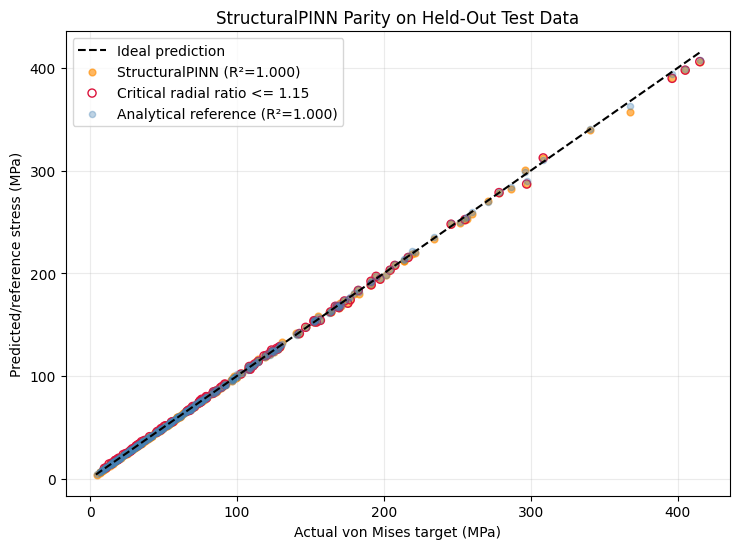

,evaluation,prediction,sample_count,R2,RMSE_MPa,MAE_MPa,MAPE_pct
0,Global test set,StructuralPINN,359,0.999602,1.424235,0.771889,1.299362
1,Critical-notch radial-ratio subset (eval_radia...,StructuralPINN,107,0.999443,2.004008,1.116894,1.185048
2,Global test set,Analytical physics reference,359,0.999810,0.985401,0.523578,0.636280
3,Critical-notch radial-ratio subset (eval_radia...,Analytical physics reference,107,0.999724,1.410198,0.734920,0.598784


In [33]:
# Global and critical-notch evaluation on the held-out test partition.
# Critical-notch means eval_radial_ratio <= 1.15; the metric is explicitly
# reported as a radial-ratio subset, not as x/r or another coordinate.
sp_model.eval()
sp_test_scaled_predictions = []
with torch.no_grad():
    for sp_batch_inputs, _, _ in sp_test_loader:
        sp_batch_predictions = sp_model(sp_batch_inputs.to(sp_device))
        sp_test_scaled_predictions.append(sp_batch_predictions.cpu().numpy())
sp_test_scaled_predictions = np.concatenate(sp_test_scaled_predictions, axis=0)
sp_test_predictions = sp_target_scaler.inverse_transform(
    sp_test_scaled_predictions
).ravel()
sp_test_actual = sp_test_df[sp_target_column].to_numpy(dtype=np.float64)
sp_test_physics_reference = sp_test_df[sp_physics_column].to_numpy(dtype=np.float64)
sp_test_radial_ratio = sp_test_df["eval_radial_ratio"].to_numpy(dtype=np.float64)

assert sp_test_predictions.shape == sp_test_actual.shape
assert np.isfinite(sp_test_predictions).all()


def sp_evaluation_metrics(actual, predictions):
    absolute_percentage_error = np.abs((predictions - actual) / actual) * 100.0
    return {
        "sample_count": len(actual),
        "R2": r2_score(actual, predictions),
        "RMSE_MPa": np.sqrt(mean_squared_error(actual, predictions)),
        "MAE_MPa": mean_absolute_error(actual, predictions),
        "MAPE_pct": float(absolute_percentage_error.mean()),
    }


sp_critical_mask = sp_test_radial_ratio <= 1.15
assert sp_critical_mask.any(), "The test set must contain critical radial-ratio samples."
sp_global_metrics = sp_evaluation_metrics(sp_test_actual, sp_test_predictions)
sp_critical_metrics = sp_evaluation_metrics(
    sp_test_actual[sp_critical_mask], sp_test_predictions[sp_critical_mask]
)
sp_physics_global_metrics = sp_evaluation_metrics(
    sp_test_actual, sp_test_physics_reference
)
sp_physics_critical_metrics = sp_evaluation_metrics(
    sp_test_actual[sp_critical_mask], sp_test_physics_reference[sp_critical_mask]
)

sp_evaluation_table = pd.DataFrame(
    [
        {"evaluation": "Global test set", "prediction": "StructuralPINN", **sp_global_metrics},
        {
            "evaluation": "Critical-notch radial-ratio subset (eval_radial_ratio <= 1.15)",
            "prediction": "StructuralPINN",
            **sp_critical_metrics,
        },
        {"evaluation": "Global test set", "prediction": "Analytical physics reference", **sp_physics_global_metrics},
        {
            "evaluation": "Critical-notch radial-ratio subset (eval_radial_ratio <= 1.15)",
            "prediction": "Analytical physics reference",
            **sp_physics_critical_metrics,
        },
    ]
)[
    [
        "evaluation",
        "prediction",
        "sample_count",
        "R2",
        "RMSE_MPa",
        "MAE_MPa",
        "MAPE_pct",
    ]
]

print("Held-out test evaluation")
print("Critical-notch condition: eval_radial_ratio <= 1.15")
print(f"Critical-notch test samples: {int(sp_critical_mask.sum())}")
print(
    sp_evaluation_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAE_MPa": "{:.4f}".format,
            "MAPE_pct": "{:.4f}".format,
        },
    )
)

sp_parity_min = min(
    sp_test_actual.min(), sp_test_predictions.min(), sp_test_physics_reference.min()
)
sp_parity_max = max(
    sp_test_actual.max(), sp_test_predictions.max(), sp_test_physics_reference.max()
)
sp_parity_figure, sp_parity_axis = plt.subplots(figsize=(7.5, 5.6))
sp_parity_axis.plot(
    [sp_parity_min, sp_parity_max],
    [sp_parity_min, sp_parity_max],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Ideal prediction",
)
sp_parity_axis.scatter(
    sp_test_actual,
    sp_test_predictions,
    s=24,
    alpha=0.62,
    color="darkorange",
    label=f"StructuralPINN (R²={sp_global_metrics['R2']:.3f})",
)
sp_parity_axis.scatter(
    sp_test_actual[sp_critical_mask],
    sp_test_predictions[sp_critical_mask],
    s=34,
    facecolors="none",
    edgecolors="crimson",
    linewidths=1.0,
    label="Critical radial ratio <= 1.15",
)
sp_parity_axis.scatter(
    sp_test_actual,
    sp_test_physics_reference,
    s=20,
    alpha=0.35,
    color="steelblue",
    label=f"Analytical reference (R²={sp_physics_global_metrics['R2']:.3f})",
)
sp_parity_axis.set_xlabel("Actual von Mises target (MPa)")
sp_parity_axis.set_ylabel("Predicted/reference stress (MPa)")
sp_parity_axis.set_title("StructuralPINN Parity on Held-Out Test Data")
sp_parity_axis.grid(alpha=0.25)
sp_parity_axis.legend()
sp_parity_figure.tight_layout()
plt.show()

sp_evaluation_table

## Baseline Surrogate Model Training \+ Evaluation \(User Pipeline\)

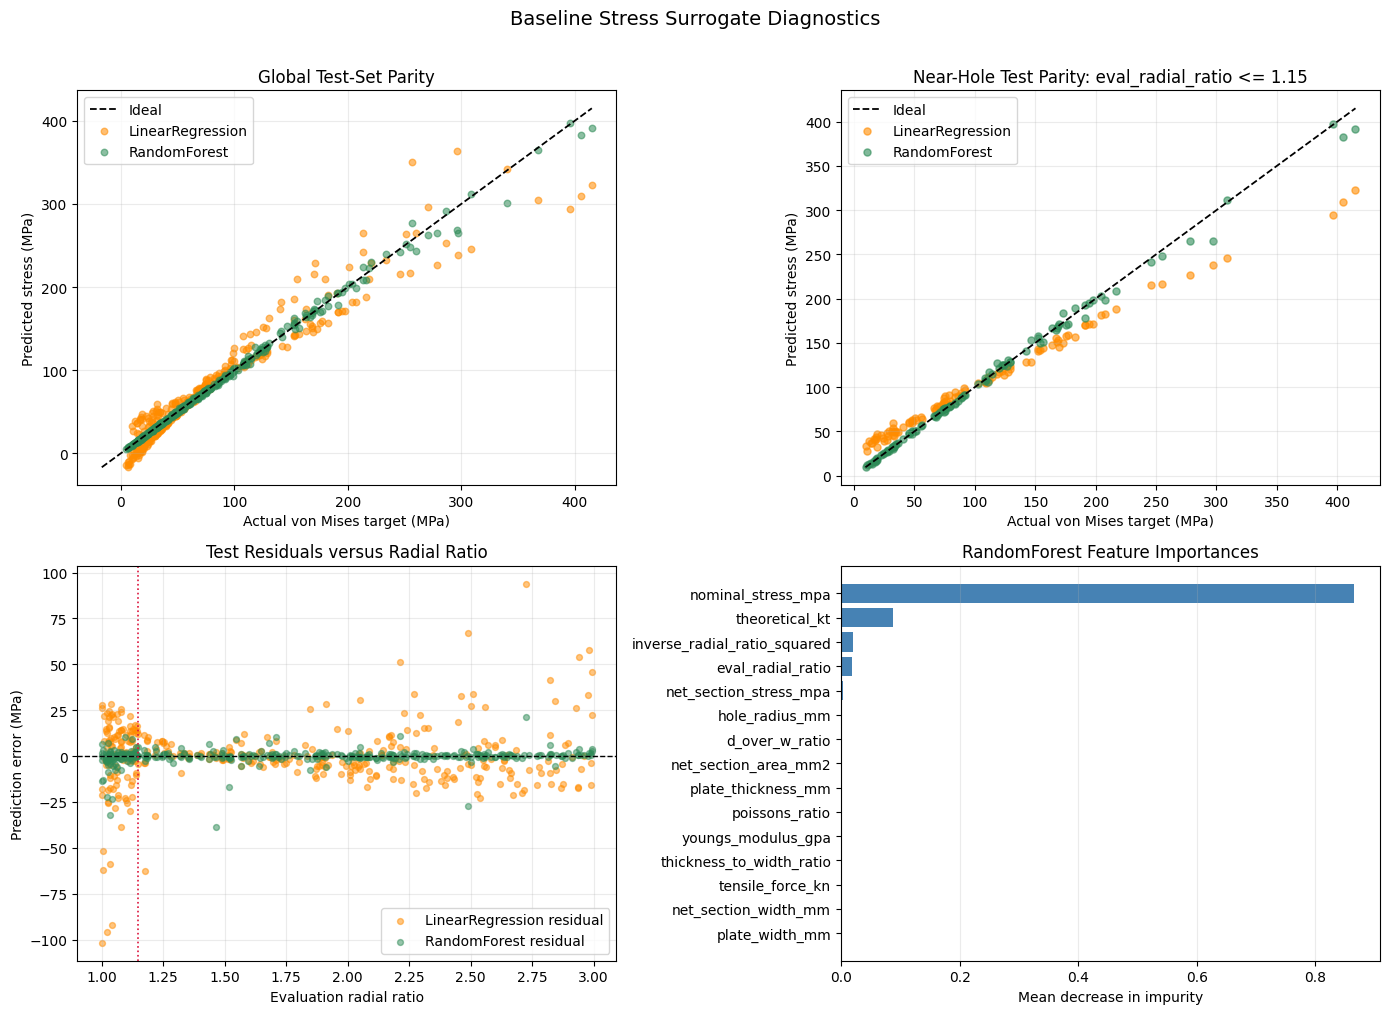

Baseline surrogate pipeline completed
Generated rows: 2400 | features used: 15
Stratified split summary:
     split  rows share  near_hole_rows radial_ratio_min radial_ratio_max
     train  1680 70.0%             512           1.0003           2.9999
validation   361 15.0%             110           1.0001           2.9961
      test   359 15.0%             107           1.0008           2.9928

Validation and held-out test metrics:
     split                                subset                        model  sample_count       R2 RMSE_MPa MAE_MPa MAPE_pct
validation                                global             LinearRegression           361 0.934789  16.9071 11.4966  30.5331
validation near-hole (eval_radial_ratio <= 1.15)             LinearRegression           110 0.929276  23.6633 18.0776  38.7302
validation                                global                 RandomForest           361 0.995705   4.3388  1.8681   2.3345
validation near-hole (eval_radial_ratio <= 1.15)        

,split,subset,model,sample_count,R2,RMSE_MPa,MAE_MPa,MAPE_pct
0,validation,global,LinearRegression,361,0.934789,16.907072,11.496575,30.533140
1,validation,near-hole (eval_radial_ratio <= 1.15),LinearRegression,110,0.929276,23.663265,18.077585,38.730202
2,validation,global,RandomForest,361,0.995705,4.338800,1.868107,2.334516
3,validation,near-hole (eval_radial_ratio <= 1.15),RandomForest,110,0.996090,5.563684,2.414474,2.393543
4,test,global,LinearRegression,359,0.933745,18.377465,11.631139,30.632047
5,test,near-hole (eval_radial_ratio <= 1.15),LinearRegression,107,0.917646,24.369928,17.285400,33.502490
6,test,global,RandomForest,359,0.996020,4.504299,1.964084,2.286482
7,test,near-hole (eval_radial_ratio <= 1.15),RandomForest,107,0.995757,5.531814,2.767468,2.380769
8,test,global,Analytical physics reference,359,0.999810,0.985401,0.523578,0.636280
9,test,near-hole (eval_radial_ratio <= 1.15),Analytical physics reference,107,0.999724,1.410198,0.734920,0.598784


In [35]:
# Baseline surrogate-model pipeline.
# Compatibility note: this block reuses the notebook's existing NumPy, pandas,
# matplotlib, pathlib, and sklearn metric imports; only LinearRegression is new.
# The generated source data stay in memory, so existing project CSVs are not overwritten.
from sklearn.linear_model import LinearRegression

baseline_seed = 2026
baseline_rng = np.random.default_rng(baseline_seed)
baseline_output_dir = Path("outputs")
baseline_output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 1. Generate a self-contained plate-with-hole surrogate dataset.
# -----------------------------------------------------------------------------
baseline_n_samples = 2400
baseline_plate_width_mm = baseline_rng.uniform(100.0, 300.0, baseline_n_samples)
baseline_d_over_w_ratio = baseline_rng.uniform(0.05, 0.35, baseline_n_samples)
baseline_hole_radius_mm = (
    0.5 * baseline_plate_width_mm * baseline_d_over_w_ratio
)
baseline_plate_thickness_mm = baseline_rng.uniform(2.0, 12.0, baseline_n_samples)
baseline_youngs_modulus_gpa = baseline_rng.uniform(180.0, 210.0, baseline_n_samples)
baseline_poissons_ratio = baseline_rng.uniform(0.27, 0.33, baseline_n_samples)
baseline_tensile_force_kn = baseline_rng.uniform(8.0, 85.0, baseline_n_samples)

# Keep a well-populated near-hole subset in every partition.
baseline_near_hole_draw = baseline_rng.random(baseline_n_samples) < 0.30
baseline_eval_radial_ratio = np.empty(baseline_n_samples)
baseline_eval_radial_ratio[baseline_near_hole_draw] = baseline_rng.uniform(
    1.0, 1.15, baseline_near_hole_draw.sum()
)
baseline_eval_radial_ratio[~baseline_near_hole_draw] = baseline_rng.uniform(
    1.15, 3.0, (~baseline_near_hole_draw).sum()
)

baseline_hole_diameter_mm = 2.0 * baseline_hole_radius_mm
baseline_nominal_stress_mpa = (
    baseline_tensile_force_kn * 1000.0
    / (baseline_plate_width_mm * baseline_plate_thickness_mm)
)
baseline_edge_theoretical_kt = (
    3.0
    - 3.14 * baseline_d_over_w_ratio
    + 3.667 * baseline_d_over_w_ratio**2
    - 1.527 * baseline_d_over_w_ratio**3
)
baseline_theoretical_kt = 1.0 + (
    baseline_edge_theoretical_kt - 1.0
) / baseline_eval_radial_ratio**2
baseline_physics_reference_mpa = (
    baseline_theoretical_kt * baseline_nominal_stress_mpa
)
baseline_von_mises_target_mpa = baseline_physics_reference_mpa * (
    1.0 + baseline_rng.normal(0.0, 0.008, baseline_n_samples)
)

baseline_raw_df = pd.DataFrame(
    {
        "sample_id": np.arange(1, baseline_n_samples + 1),
        "plate_width_mm": baseline_plate_width_mm,
        "hole_radius_mm": baseline_hole_radius_mm,
        "plate_thickness_mm": baseline_plate_thickness_mm,
        "d_over_w_ratio": baseline_d_over_w_ratio,
        "youngs_modulus_gpa": baseline_youngs_modulus_gpa,
        "poissons_ratio": baseline_poissons_ratio,
        "tensile_force_kn": baseline_tensile_force_kn,
        "eval_radial_ratio": baseline_eval_radial_ratio,
        "theoretical_kt": baseline_theoretical_kt,
        "von_mises_target_mpa": baseline_von_mises_target_mpa,
    }
)

# -----------------------------------------------------------------------------
# 2. Engineer physically meaningful input features.
# -----------------------------------------------------------------------------
baseline_feature_df = baseline_raw_df.copy()
baseline_feature_df["hole_diameter_mm"] = 2.0 * baseline_feature_df["hole_radius_mm"]
baseline_feature_df["nominal_stress_mpa"] = (
    baseline_feature_df["tensile_force_kn"] * 1000.0
    / (
        baseline_feature_df["plate_width_mm"]
        * baseline_feature_df["plate_thickness_mm"]
    )
)
baseline_feature_df["net_section_width_mm"] = (
    baseline_feature_df["plate_width_mm"]
    - baseline_feature_df["hole_diameter_mm"]
)
baseline_feature_df["net_section_area_mm2"] = (
    baseline_feature_df["net_section_width_mm"]
    * baseline_feature_df["plate_thickness_mm"]
)
baseline_feature_df["net_section_stress_mpa"] = (
    baseline_feature_df["tensile_force_kn"] * 1000.0
    / baseline_feature_df["net_section_area_mm2"]
)
baseline_feature_df["inverse_radial_ratio_squared"] = (
    1.0 / baseline_feature_df["eval_radial_ratio"] ** 2
)
baseline_feature_df["thickness_to_width_ratio"] = (
    baseline_feature_df["plate_thickness_mm"]
    / baseline_feature_df["plate_width_mm"]
)
baseline_feature_df["physics_reference_mpa"] = baseline_physics_reference_mpa

baseline_feature_columns = [
    "plate_width_mm",
    "hole_radius_mm",
    "plate_thickness_mm",
    "d_over_w_ratio",
    "youngs_modulus_gpa",
    "poissons_ratio",
    "tensile_force_kn",
    "eval_radial_ratio",
    "theoretical_kt",
    "nominal_stress_mpa",
    "net_section_stress_mpa",
    "net_section_width_mm",
    "net_section_area_mm2",
    "inverse_radial_ratio_squared",
    "thickness_to_width_ratio",
]
baseline_target_column = "von_mises_target_mpa"
baseline_physics_column = "physics_reference_mpa"

# The analytical physics reference is retained for comparison, but deliberately
# excluded from model inputs because it is a direct target proxy.
baseline_expected_kt = 1.0 + (
    (
        3.0
        - 3.14 * baseline_feature_df["d_over_w_ratio"]
        + 3.667 * baseline_feature_df["d_over_w_ratio"] ** 2
        - 1.527 * baseline_feature_df["d_over_w_ratio"] ** 3
    )
    - 1.0
) / baseline_feature_df["eval_radial_ratio"] ** 2
assert np.allclose(
    baseline_feature_df["theoretical_kt"], baseline_expected_kt, rtol=0, atol=1e-12
)
assert np.allclose(
    baseline_feature_df["d_over_w_ratio"],
    baseline_feature_df["hole_diameter_mm"] / baseline_feature_df["plate_width_mm"],
    rtol=0,
    atol=1e-12,
)
assert baseline_feature_df[baseline_feature_columns + [baseline_target_column]].notna().all().all()
assert (baseline_feature_df["net_section_width_mm"] > 0).all()
assert (baseline_feature_df[baseline_target_column] > 0).all()

# -----------------------------------------------------------------------------
# 3. Stratified 70/15/15 train/validation/test split.
# -----------------------------------------------------------------------------
baseline_feature_df["geometry_stratum"] = pd.qcut(
    baseline_feature_df["d_over_w_ratio"],
    q=10,
    labels=False,
    duplicates="drop",
)
baseline_feature_df["radial_stratum"] = pd.cut(
    baseline_feature_df["eval_radial_ratio"],
    bins=[1.0, 1.15, 1.5, 2.0, 3.0],
    labels=False,
    include_lowest=True,
    right=True,
)
baseline_feature_df["split_stratum"] = (
    baseline_feature_df["geometry_stratum"].astype(str)
    + "_"
    + baseline_feature_df["radial_stratum"].astype(str)
)

baseline_split_rng = np.random.default_rng(baseline_seed + 1)
baseline_train_parts, baseline_validation_parts, baseline_test_parts = [], [], []
for _, baseline_stratum_df in baseline_feature_df.groupby("split_stratum", sort=True):
    baseline_indices = baseline_split_rng.permutation(
        baseline_stratum_df.index.to_numpy()
    )
    baseline_stratum_size = len(baseline_indices)
    baseline_n_train = int(round(0.70 * baseline_stratum_size))
    baseline_n_validation = int(round(0.15 * baseline_stratum_size))
    baseline_train_parts.append(
        baseline_feature_df.loc[baseline_indices[:baseline_n_train]]
    )
    baseline_validation_parts.append(
        baseline_feature_df.loc[
            baseline_indices[baseline_n_train : baseline_n_train + baseline_n_validation]
        ]
    )
    baseline_test_parts.append(
        baseline_feature_df.loc[
            baseline_indices[baseline_n_train + baseline_n_validation :]
        ]
    )

baseline_train_df = (
    pd.concat(baseline_train_parts)
    .sample(frac=1.0, random_state=baseline_seed)
    .reset_index(drop=True)
)
baseline_validation_df = (
    pd.concat(baseline_validation_parts)
    .sample(frac=1.0, random_state=baseline_seed)
    .reset_index(drop=True)
)
baseline_test_df = (
    pd.concat(baseline_test_parts)
    .sample(frac=1.0, random_state=baseline_seed)
    .reset_index(drop=True)
)

baseline_train_ids = set(baseline_train_df["sample_id"])
baseline_validation_ids = set(baseline_validation_df["sample_id"])
baseline_test_ids = set(baseline_test_df["sample_id"])
assert baseline_train_ids.isdisjoint(baseline_validation_ids)
assert baseline_train_ids.isdisjoint(baseline_test_ids)
assert baseline_validation_ids.isdisjoint(baseline_test_ids)
assert (
    len(baseline_train_df)
    + len(baseline_validation_df)
    + len(baseline_test_df)
    == baseline_n_samples
)
assert baseline_test_df["eval_radial_ratio"].between(1.0, 3.0).all()

baseline_split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(baseline_train_df),
            len(baseline_validation_df),
            len(baseline_test_df),
        ],
        "share": [
            len(baseline_train_df) / baseline_n_samples,
            len(baseline_validation_df) / baseline_n_samples,
            len(baseline_test_df) / baseline_n_samples,
        ],
        "near_hole_rows": [
            (baseline_train_df["eval_radial_ratio"] <= 1.15).sum(),
            (baseline_validation_df["eval_radial_ratio"] <= 1.15).sum(),
            (baseline_test_df["eval_radial_ratio"] <= 1.15).sum(),
        ],
        "radial_ratio_min": [
            baseline_train_df["eval_radial_ratio"].min(),
            baseline_validation_df["eval_radial_ratio"].min(),
            baseline_test_df["eval_radial_ratio"].min(),
        ],
        "radial_ratio_max": [
            baseline_train_df["eval_radial_ratio"].max(),
            baseline_validation_df["eval_radial_ratio"].max(),
            baseline_test_df["eval_radial_ratio"].max(),
        ],
    }
)

# -----------------------------------------------------------------------------
# 4. Train LinearRegression and RandomForest models using train data only.
# -----------------------------------------------------------------------------
baseline_X_train = baseline_train_df[baseline_feature_columns]
baseline_y_train = baseline_train_df[baseline_target_column].to_numpy()
baseline_X_validation = baseline_validation_df[baseline_feature_columns]
baseline_y_validation = baseline_validation_df[baseline_target_column].to_numpy()
baseline_X_test = baseline_test_df[baseline_feature_columns]
baseline_y_test = baseline_test_df[baseline_target_column].to_numpy()

baseline_linear_model = LinearRegression()
baseline_linear_model.fit(baseline_X_train, baseline_y_train)

baseline_rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=baseline_seed,
    n_jobs=1,
    min_samples_leaf=2,
)
baseline_rf_model.fit(baseline_X_train, baseline_y_train)

baseline_predictions = {
    "LinearRegression": {
        "train": baseline_linear_model.predict(baseline_X_train),
        "validation": baseline_linear_model.predict(baseline_X_validation),
        "test": baseline_linear_model.predict(baseline_X_test),
    },
    "RandomForest": {
        "train": baseline_rf_model.predict(baseline_X_train),
        "validation": baseline_rf_model.predict(baseline_X_validation),
        "test": baseline_rf_model.predict(baseline_X_test),
    },
}


def baseline_regression_metrics(actual, predictions):
    actual = np.asarray(actual, dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    assert np.isfinite(actual).all() and np.isfinite(predictions).all()
    assert (actual != 0).all(), "MAPE requires nonzero targets."
    return {
        "sample_count": len(actual),
        "R2": r2_score(actual, predictions),
        # Use sqrt(MSE) instead of squared=False for sklearn-version compatibility.
        "RMSE_MPa": np.sqrt(mean_squared_error(actual, predictions)),
        "MAE_MPa": mean_absolute_error(actual, predictions),
        "MAPE_pct": float(np.mean(np.abs((predictions - actual) / actual)) * 100.0),
    }


baseline_near_hole_mask = baseline_test_df["eval_radial_ratio"].to_numpy() <= 1.15
assert baseline_near_hole_mask.any()
baseline_metric_rows = []
for baseline_split_name, baseline_actual, baseline_mask in [
    (
        "validation",
        baseline_y_validation,
        baseline_validation_df["eval_radial_ratio"].to_numpy() <= 1.15,
    ),
    ("test", baseline_y_test, baseline_near_hole_mask),
]:
    for baseline_model_name, baseline_model_predictions in baseline_predictions.items():
        baseline_global_metrics = baseline_regression_metrics(
            baseline_actual, baseline_model_predictions[baseline_split_name]
        )
        baseline_metric_rows.append(
            {
                "split": baseline_split_name,
                "subset": "global",
                "model": baseline_model_name,
                **baseline_global_metrics,
            }
        )
        baseline_near_hole_metrics = baseline_regression_metrics(
            baseline_actual[baseline_mask],
            baseline_model_predictions[baseline_split_name][baseline_mask],
        )
        baseline_metric_rows.append(
            {
                "split": baseline_split_name,
                "subset": "near-hole (eval_radial_ratio <= 1.15)",
                "model": baseline_model_name,
                **baseline_near_hole_metrics,
            }
        )

# Benchmark the analytical reference separately; it is not a learned model.
baseline_test_physics_reference = baseline_test_df[baseline_physics_column].to_numpy()
baseline_metric_rows.append(
    {
        "split": "test",
        "subset": "global",
        "model": "Analytical physics reference",
        **baseline_regression_metrics(baseline_y_test, baseline_test_physics_reference),
    }
)
baseline_metric_rows.append(
    {
        "split": "test",
        "subset": "near-hole (eval_radial_ratio <= 1.15)",
        "model": "Analytical physics reference",
        **baseline_regression_metrics(
            baseline_y_test[baseline_near_hole_mask],
            baseline_test_physics_reference[baseline_near_hole_mask],
        ),
    }
)
baseline_metric_table = pd.DataFrame(baseline_metric_rows)

# -----------------------------------------------------------------------------
# 5. Feature importances, diagnostics, and test-prediction artifact.
# -----------------------------------------------------------------------------
baseline_rf_feature_importance = (
    pd.DataFrame(
        {
            "feature": baseline_feature_columns,
            "importance": baseline_rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
baseline_linear_coefficients = (
    pd.DataFrame(
        {
            "feature": baseline_feature_columns,
            "coefficient": baseline_linear_model.coef_,
            "absolute_coefficient": np.abs(baseline_linear_model.coef_),
        }
    )
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

baseline_test_linear_predictions = baseline_predictions["LinearRegression"]["test"]
baseline_test_rf_predictions = baseline_predictions["RandomForest"]["test"]
baseline_test_linear_residuals = baseline_test_linear_predictions - baseline_y_test
baseline_test_rf_residuals = baseline_test_rf_predictions - baseline_y_test

baseline_plot_min = min(
    baseline_y_test.min(),
    baseline_test_linear_predictions.min(),
    baseline_test_rf_predictions.min(),
    baseline_test_physics_reference.min(),
)
baseline_plot_max = max(
    baseline_y_test.max(),
    baseline_test_linear_predictions.max(),
    baseline_test_rf_predictions.max(),
    baseline_test_physics_reference.max(),
)
baseline_diagnostic_figure, baseline_diagnostic_axes = plt.subplots(
    2, 2, figsize=(14, 10)
)

# Global parity.
baseline_diagnostic_axes[0, 0].plot(
    [baseline_plot_min, baseline_plot_max],
    [baseline_plot_min, baseline_plot_max],
    "k--",
    linewidth=1.3,
    label="Ideal",
)
baseline_diagnostic_axes[0, 0].scatter(
    baseline_y_test,
    baseline_test_linear_predictions,
    s=22,
    alpha=0.55,
    color="darkorange",
    label="LinearRegression",
)
baseline_diagnostic_axes[0, 0].scatter(
    baseline_y_test,
    baseline_test_rf_predictions,
    s=22,
    alpha=0.55,
    color="seagreen",
    label="RandomForest",
)
baseline_diagnostic_axes[0, 0].set_title("Global Test-Set Parity")
baseline_diagnostic_axes[0, 0].set_xlabel("Actual von Mises target (MPa)")
baseline_diagnostic_axes[0, 0].set_ylabel("Predicted stress (MPa)")
baseline_diagnostic_axes[0, 0].grid(alpha=0.25)
baseline_diagnostic_axes[0, 0].legend()

# Near-hole parity.
baseline_near_hole_actual = baseline_y_test[baseline_near_hole_mask]
baseline_near_hole_linear = baseline_test_linear_predictions[baseline_near_hole_mask]
baseline_near_hole_rf = baseline_test_rf_predictions[baseline_near_hole_mask]
baseline_near_min = min(
    baseline_near_hole_actual.min(), baseline_near_hole_linear.min(), baseline_near_hole_rf.min()
)
baseline_near_max = max(
    baseline_near_hole_actual.max(), baseline_near_hole_linear.max(), baseline_near_hole_rf.max()
)
baseline_diagnostic_axes[0, 1].plot(
    [baseline_near_min, baseline_near_max],
    [baseline_near_min, baseline_near_max],
    "k--",
    linewidth=1.3,
    label="Ideal",
)
baseline_diagnostic_axes[0, 1].scatter(
    baseline_near_hole_actual,
    baseline_near_hole_linear,
    s=26,
    alpha=0.60,
    color="darkorange",
    label="LinearRegression",
)
baseline_diagnostic_axes[0, 1].scatter(
    baseline_near_hole_actual,
    baseline_near_hole_rf,
    s=26,
    alpha=0.60,
    color="seagreen",
    label="RandomForest",
)
baseline_diagnostic_axes[0, 1].set_title("Near-Hole Test Parity: eval_radial_ratio <= 1.15")
baseline_diagnostic_axes[0, 1].set_xlabel("Actual von Mises target (MPa)")
baseline_diagnostic_axes[0, 1].set_ylabel("Predicted stress (MPa)")
baseline_diagnostic_axes[0, 1].grid(alpha=0.25)
baseline_diagnostic_axes[0, 1].legend()

# Residual behavior versus radial distance.
baseline_diagnostic_axes[1, 0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
baseline_diagnostic_axes[1, 0].scatter(
    baseline_test_df["eval_radial_ratio"],
    baseline_test_linear_residuals,
    s=18,
    alpha=0.50,
    color="darkorange",
    label="LinearRegression residual",
)
baseline_diagnostic_axes[1, 0].scatter(
    baseline_test_df["eval_radial_ratio"],
    baseline_test_rf_residuals,
    s=18,
    alpha=0.50,
    color="seagreen",
    label="RandomForest residual",
)
baseline_diagnostic_axes[1, 0].axvline(1.15, color="crimson", linestyle=":", linewidth=1.2)
baseline_diagnostic_axes[1, 0].set_title("Test Residuals versus Radial Ratio")
baseline_diagnostic_axes[1, 0].set_xlabel("Evaluation radial ratio")
baseline_diagnostic_axes[1, 0].set_ylabel("Prediction error (MPa)")
baseline_diagnostic_axes[1, 0].grid(alpha=0.25)
baseline_diagnostic_axes[1, 0].legend()

# RandomForest feature-importance ranking.
baseline_importance_plot = baseline_rf_feature_importance.sort_values(
    "importance", ascending=True
)
baseline_diagnostic_axes[1, 1].barh(
    baseline_importance_plot["feature"],
    baseline_importance_plot["importance"],
    color="steelblue",
)
baseline_diagnostic_axes[1, 1].set_title("RandomForest Feature Importances")
baseline_diagnostic_axes[1, 1].set_xlabel("Mean decrease in impurity")
baseline_diagnostic_axes[1, 1].grid(axis="x", alpha=0.25)

baseline_diagnostic_figure.suptitle(
    "Baseline Stress Surrogate Diagnostics", y=1.01, fontsize=14
)
baseline_diagnostic_figure.tight_layout()
baseline_diagnostics_path = baseline_output_dir / "stress_surrogate_diagnostics.png"
baseline_diagnostic_figure.savefig(
    baseline_diagnostics_path, dpi=160, bbox_inches="tight"
)
plt.show()

baseline_prediction_df = baseline_test_df[
    ["sample_id", "d_over_w_ratio", "eval_radial_ratio"]
].copy()
baseline_prediction_df["near_hole"] = baseline_near_hole_mask
baseline_prediction_df["actual_von_mises_target_mpa"] = baseline_y_test
baseline_prediction_df["analytical_physics_reference_mpa"] = baseline_test_physics_reference
baseline_prediction_df["linear_regression_prediction_mpa"] = baseline_test_linear_predictions
baseline_prediction_df["random_forest_prediction_mpa"] = baseline_test_rf_predictions
baseline_prediction_df["linear_regression_error_mpa"] = baseline_test_linear_residuals
baseline_prediction_df["random_forest_error_mpa"] = baseline_test_rf_residuals
baseline_predictions_path = baseline_output_dir / "stress_surrogate_test_predictions.csv"
baseline_prediction_df.to_csv(baseline_predictions_path, index=False)

print("Baseline surrogate pipeline completed")
print(f"Generated rows: {len(baseline_raw_df)} | features used: {len(baseline_feature_columns)}")
print("Stratified split summary:")
print(
    baseline_split_summary.to_string(
        index=False,
        formatters={
            "share": "{:.1%}".format,
            "radial_ratio_min": "{:.4f}".format,
            "radial_ratio_max": "{:.4f}".format,
        },
    )
)
print("\nValidation and held-out test metrics:")
print(
    baseline_metric_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAE_MPa": "{:.4f}".format,
            "MAPE_pct": "{:.4f}".format,
        },
    )
)
print("\nTop RandomForest feature importances:")
print(
    baseline_rf_feature_importance.head(10).to_string(
        index=False, formatters={"importance": "{:.6f}".format}
    )
)
print(f"Diagnostics artifact: {baseline_diagnostics_path.resolve()}")
print(f"Prediction artifact: {baseline_predictions_path.resolve()}")

baseline_metric_table

## Optimized PINN Training Pipeline \(Isolated and Reproducible\)

This section creates a fresh synthetic structural dataset in memory, fits normalization on the training partition only, and uses prefixed variables and objects\. It does not overwrite the project CSV files, earlier models, figures, or prediction artifacts\. The physics objective emphasizes the near\-hole spatial region while retaining a supervised target objective; MAPE is computed only over nonzero targets\.

In [37]:
# Optimized PINN definitions. All names are prefixed with opt_ to preserve earlier state.
opt_seed = 2027


def opt_set_deterministic(seed):
    """Configure reproducible NumPy and PyTorch execution for this section."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)
    torch.use_deterministic_algorithms(True)


def opt_generate_surrogate_dataset(n_samples=2400, seed=2027):
    """Generate a self-contained plate-with-hole stress-concentration dataset."""
    opt_rng = np.random.default_rng(seed)
    opt_width_mm = opt_rng.uniform(100.0, 300.0, n_samples)
    opt_d_over_w = opt_rng.uniform(0.05, 0.35, n_samples)
    opt_hole_radius_mm = 0.5 * opt_width_mm * opt_d_over_w
    opt_thickness_mm = opt_rng.uniform(2.0, 12.0, n_samples)
    opt_youngs_modulus_gpa = opt_rng.uniform(180.0, 210.0, n_samples)
    opt_poissons_ratio = opt_rng.uniform(0.27, 0.33, n_samples)
    opt_tensile_force_kn = opt_rng.uniform(8.0, 85.0, n_samples)

    # Populate every split with a meaningful near-hole region.
    opt_near_hole_draw = opt_rng.random(n_samples) < 0.30
    opt_eval_radial_ratio = np.empty(n_samples)
    opt_eval_radial_ratio[opt_near_hole_draw] = opt_rng.uniform(
        1.0, 1.15, opt_near_hole_draw.sum()
    )
    opt_eval_radial_ratio[~opt_near_hole_draw] = opt_rng.uniform(
        1.15, 3.0, (~opt_near_hole_draw).sum()
    )

    opt_hole_diameter_mm = 2.0 * opt_hole_radius_mm
    opt_nominal_stress_mpa = (
        opt_tensile_force_kn * 1000.0
        / (opt_width_mm * opt_thickness_mm)
    )
    opt_edge_kt = (
        3.0
        - 3.14 * opt_d_over_w
        + 3.667 * opt_d_over_w**2
        - 1.527 * opt_d_over_w**3
    )
    # The radial field approaches Kt=1 away from the hole and equals edge Kt at r/R=1.
    opt_theoretical_kt = 1.0 + (opt_edge_kt - 1.0) / opt_eval_radial_ratio**2
    opt_physics_reference_mpa = opt_theoretical_kt * opt_nominal_stress_mpa
    opt_target_mpa = opt_physics_reference_mpa * (
        1.0 + opt_rng.normal(0.0, 0.008, n_samples)
    )

    opt_columns = [
        "plate_width_mm",
        "hole_radius_mm",
        "plate_thickness_mm",
        "d_over_w_ratio",
        "youngs_modulus_gpa",
        "poissons_ratio",
        "tensile_force_kn",
        "eval_radial_ratio",
        "theoretical_kt",
        "von_mises_target_mpa",
    ]
    return pd.DataFrame(
        {
            "plate_width_mm": opt_width_mm,
            "hole_radius_mm": opt_hole_radius_mm,
            "plate_thickness_mm": opt_thickness_mm,
            "d_over_w_ratio": opt_d_over_w,
            "youngs_modulus_gpa": opt_youngs_modulus_gpa,
            "poissons_ratio": opt_poissons_ratio,
            "tensile_force_kn": opt_tensile_force_kn,
            "eval_radial_ratio": opt_eval_radial_ratio,
            "theoretical_kt": opt_theoretical_kt,
            "von_mises_target_mpa": opt_target_mpa,
        }
    )[opt_columns]


def opt_prepare_features(opt_raw_frame):
    """Create physically defined inputs and the analytical physics reference."""
    opt_frame = opt_raw_frame.copy()
    opt_frame["hole_diameter_mm"] = 2.0 * opt_frame["hole_radius_mm"]
    opt_frame["nominal_stress_mpa"] = (
        opt_frame["tensile_force_kn"] * 1000.0
        / (opt_frame["plate_width_mm"] * opt_frame["plate_thickness_mm"])
    )
    opt_frame["net_section_width_mm"] = (
        opt_frame["plate_width_mm"] - opt_frame["hole_diameter_mm"]
    )
    opt_frame["net_section_area_mm2"] = (
        opt_frame["net_section_width_mm"] * opt_frame["plate_thickness_mm"]
    )
    opt_frame["net_section_stress_mpa"] = (
        opt_frame["tensile_force_kn"] * 1000.0
        / opt_frame["net_section_area_mm2"]
    )
    opt_frame["inverse_radial_ratio_squared"] = (
        1.0 / opt_frame["eval_radial_ratio"] ** 2
    )
    opt_frame["thickness_to_width_ratio"] = (
        opt_frame["plate_thickness_mm"] / opt_frame["plate_width_mm"]
    )
    opt_frame["physics_reference_mpa"] = (
        opt_frame["theoretical_kt"] * opt_frame["nominal_stress_mpa"]
    )

    opt_expected_kt = 1.0 + (
        (
            3.0
            - 3.14 * opt_frame["d_over_w_ratio"]
            + 3.667 * opt_frame["d_over_w_ratio"] ** 2
            - 1.527 * opt_frame["d_over_w_ratio"] ** 3
        )
        - 1.0
    ) / opt_frame["eval_radial_ratio"] ** 2
    assert np.allclose(
        opt_frame["theoretical_kt"], opt_expected_kt, rtol=0, atol=1e-12
    )
    assert np.allclose(
        opt_frame["d_over_w_ratio"],
        opt_frame["hole_diameter_mm"] / opt_frame["plate_width_mm"],
        rtol=0,
        atol=1e-12,
    )
    assert (opt_frame["net_section_width_mm"] > 0).all()
    assert opt_frame.notna().all().all()
    return opt_frame


class OptimizedStructuralPINN(nn.Module):
    """Compact normalized PINN for sample-level stress prediction."""

    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1),
        )

    def forward(self, inputs):
        return self.network(inputs)


def opt_spatially_weighted_physics_loss(
    predictions,
    targets,
    physics_reference,
    eval_radial_ratio,
    supervised_weight=0.70,
    physics_weight=0.30,
    critical_threshold=1.15,
    near_hole_boost=4.0,
    epsilon=1e-8,
):
    """Combine normalized data and near-hole-weighted physics objectives."""
    opt_radial = eval_radial_ratio.reshape(-1, 1)
    opt_inverse_radial_weight = 1.0 / opt_radial.pow(2).clamp_min(epsilon)
    opt_critical_multiplier = torch.where(
        opt_radial <= critical_threshold,
        torch.full_like(opt_radial, 1.5),
        torch.ones_like(opt_radial),
    )
    opt_spatial_weights = 1.0 + near_hole_boost * opt_inverse_radial_weight
    opt_spatial_weights = opt_spatial_weights * opt_critical_multiplier
    opt_spatial_weights = opt_spatial_weights / opt_spatial_weights.mean().clamp_min(epsilon)

    opt_supervised_mse = nn.functional.mse_loss(predictions, targets)
    opt_physics_mse = (
        opt_spatial_weights * (predictions - physics_reference).pow(2)
    ).mean()
    opt_target_scale = targets.pow(2).mean().clamp_min(epsilon)
    opt_physics_scale = (
        opt_spatial_weights * physics_reference.pow(2)
    ).mean().clamp_min(epsilon)
    opt_normalized_supervised = opt_supervised_mse / opt_target_scale
    opt_normalized_physics = opt_physics_mse / opt_physics_scale
    opt_total = (
        supervised_weight * opt_normalized_supervised
        + physics_weight * opt_normalized_physics
    )
    return opt_total, opt_normalized_supervised, opt_normalized_physics


def opt_train_pinn(
    opt_train_frame,
    opt_validation_frame,
    opt_feature_columns,
    opt_target_column,
    opt_physics_column,
    seed=2027,
    max_epochs=900,
    patience=120,
    batch_size=128,
    supervised_weight=0.70,
    physics_weight=0.30,
):
    """Train deterministically with train-only scalers and validation early stopping."""
    opt_set_deterministic(seed)
    opt_device = torch.device("cpu")
    opt_input_scaler = StandardScaler().fit(
        opt_train_frame[opt_feature_columns]
    )
    opt_target_scaler = StandardScaler().fit(
        opt_train_frame[[opt_target_column]]
    )

    def opt_scaled_arrays(opt_frame):
        opt_inputs = opt_input_scaler.transform(
            opt_frame[opt_feature_columns]
        ).astype(np.float32)
        opt_targets = opt_target_scaler.transform(
            opt_frame[[opt_target_column]]
        ).astype(np.float32)
        opt_physics = opt_target_scaler.transform(
            opt_frame[[opt_physics_column]].rename(
                columns={opt_physics_column: opt_target_column}
            )
        ).astype(np.float32)
        opt_radial = opt_frame["eval_radial_ratio"].to_numpy(
            dtype=np.float32
        ).reshape(-1, 1)
        return opt_inputs, opt_targets, opt_physics, opt_radial

    opt_X_train, opt_y_train, opt_ref_train, opt_radial_train = opt_scaled_arrays(
        opt_train_frame
    )
    opt_X_validation, opt_y_validation, opt_ref_validation, opt_radial_validation = opt_scaled_arrays(
        opt_validation_frame
    )

    opt_train_dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(opt_X_train),
        torch.from_numpy(opt_y_train),
        torch.from_numpy(opt_ref_train),
        torch.from_numpy(opt_radial_train),
    )
    opt_validation_dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(opt_X_validation),
        torch.from_numpy(opt_y_validation),
        torch.from_numpy(opt_ref_validation),
        torch.from_numpy(opt_radial_validation),
    )
    opt_loader_generator = torch.Generator().manual_seed(seed + 1)
    opt_train_loader = torch.utils.data.DataLoader(
        opt_train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=opt_loader_generator,
        num_workers=0,
    )
    opt_validation_loader = torch.utils.data.DataLoader(
        opt_validation_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0,
    )

    torch.manual_seed(seed)
    opt_model = OptimizedStructuralPINN(len(opt_feature_columns)).to(opt_device)
    opt_optimizer = torch.optim.AdamW(
        opt_model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    opt_best_state = None
    opt_best_validation_loss = float("inf")
    opt_best_epoch = 0
    opt_wait = 0
    opt_history = []

    for opt_epoch in range(max_epochs):
        opt_model.train()
        opt_train_total = 0.0
        opt_train_supervised = 0.0
        opt_train_physics = 0.0
        opt_train_count = 0
        for (
            opt_batch_inputs,
            opt_batch_targets,
            opt_batch_physics,
            opt_batch_radial,
        ) in opt_train_loader:
            opt_optimizer.zero_grad(set_to_none=True)
            opt_batch_predictions = opt_model(opt_batch_inputs.to(opt_device))
            opt_batch_total, opt_batch_supervised, opt_batch_physics_loss = (
                opt_spatially_weighted_physics_loss(
                    opt_batch_predictions,
                    opt_batch_targets.to(opt_device),
                    opt_batch_physics.to(opt_device),
                    opt_batch_radial.to(opt_device),
                    supervised_weight=supervised_weight,
                    physics_weight=physics_weight,
                )
            )
            opt_batch_total.backward()
            opt_optimizer.step()
            opt_batch_size = opt_batch_inputs.shape[0]
            opt_train_count += opt_batch_size
            opt_train_total += float(opt_batch_total.detach()) * opt_batch_size
            opt_train_supervised += float(opt_batch_supervised.detach()) * opt_batch_size
            opt_train_physics += float(opt_batch_physics_loss.detach()) * opt_batch_size

        opt_model.eval()
        opt_validation_total = 0.0
        opt_validation_supervised = 0.0
        opt_validation_physics = 0.0
        opt_validation_count = 0
        with torch.no_grad():
            for (
                opt_batch_inputs,
                opt_batch_targets,
                opt_batch_physics,
                opt_batch_radial,
            ) in opt_validation_loader:
                opt_batch_size = opt_batch_inputs.shape[0]
                opt_batch_predictions = opt_model(opt_batch_inputs.to(opt_device))
                opt_batch_total, opt_batch_supervised, opt_batch_physics_loss = (
                    opt_spatially_weighted_physics_loss(
                        opt_batch_predictions,
                        opt_batch_targets.to(opt_device),
                        opt_batch_physics.to(opt_device),
                        opt_batch_radial.to(opt_device),
                        supervised_weight=supervised_weight,
                        physics_weight=physics_weight,
                    )
                )
                opt_validation_count += opt_batch_size
                opt_validation_total += float(opt_batch_total) * opt_batch_size
                opt_validation_supervised += float(opt_batch_supervised) * opt_batch_size
                opt_validation_physics += float(opt_batch_physics_loss) * opt_batch_size

        opt_epoch_metrics = {
            "epoch": opt_epoch + 1,
            "train_total_loss": opt_train_total / opt_train_count,
            "train_supervised_loss": opt_train_supervised / opt_train_count,
            "train_physics_loss": opt_train_physics / opt_train_count,
            "validation_total_loss": opt_validation_total / opt_validation_count,
            "validation_supervised_loss": opt_validation_supervised / opt_validation_count,
            "validation_physics_loss": opt_validation_physics / opt_validation_count,
        }
        opt_history.append(opt_epoch_metrics)

        if opt_epoch_metrics["validation_total_loss"] < opt_best_validation_loss - 1e-8:
            opt_best_validation_loss = opt_epoch_metrics["validation_total_loss"]
            opt_best_epoch = opt_epoch + 1
            opt_best_state = {
                opt_name: opt_parameter.detach().clone()
                for opt_name, opt_parameter in opt_model.state_dict().items()
            }
            opt_wait = 0
        else:
            opt_wait += 1
            if opt_wait >= patience:
                break

    assert opt_best_state is not None
    opt_model.load_state_dict(opt_best_state)
    opt_model.eval()
    return {
        "model": opt_model,
        "input_scaler": opt_input_scaler,
        "target_scaler": opt_target_scaler,
        "feature_columns": list(opt_feature_columns),
        "target_column": opt_target_column,
        "physics_column": opt_physics_column,
        "device": opt_device,
        "best_epoch": opt_best_epoch,
        "best_validation_loss": opt_best_validation_loss,
        "history": pd.DataFrame(opt_history),
    }


def opt_predict_pinn(opt_fit, opt_frame):
    """Predict raw-unit stress values from a fitted optimized PINN."""
    opt_inputs = opt_fit["input_scaler"].transform(
        opt_frame[opt_fit["feature_columns"]]
    ).astype(np.float32)
    opt_model = opt_fit["model"]
    opt_was_training = opt_model.training
    opt_model.eval()
    with torch.no_grad():
        opt_scaled_predictions = opt_model(
            torch.from_numpy(opt_inputs).to(opt_fit["device"])
        ).cpu().numpy()
    if opt_was_training:
        opt_model.train()
    return opt_fit["target_scaler"].inverse_transform(
        opt_scaled_predictions
    ).ravel()


def opt_regression_metrics(opt_actual, opt_predictions, epsilon=1e-12):
    """Return regression metrics with MAPE guarded against zero targets."""
    opt_actual = np.asarray(opt_actual, dtype=float).ravel()
    opt_predictions = np.asarray(opt_predictions, dtype=float).ravel()
    assert opt_actual.shape == opt_predictions.shape
    assert np.isfinite(opt_actual).all() and np.isfinite(opt_predictions).all()
    opt_nonzero = np.abs(opt_actual) > epsilon
    if opt_nonzero.any():
        opt_mape = float(
            np.mean(
                np.abs(opt_predictions[opt_nonzero] - opt_actual[opt_nonzero])
                / np.abs(opt_actual[opt_nonzero])
            )
            * 100.0
        )
    else:
        opt_mape = float("nan")
    return {
        "sample_count": int(opt_actual.size),
        "R2": r2_score(opt_actual, opt_predictions),
        "RMSE_MPa": np.sqrt(mean_squared_error(opt_actual, opt_predictions)),
        "MAE_MPa": mean_absolute_error(opt_actual, opt_predictions),
        "MAPE_pct": opt_mape,
    }

print("Optimized PINN definitions loaded: generator, model, spatially weighted loss, trainer, predictor, and metrics.")

Optimized PINN definitions loaded: generator, model, spatially weighted loss, trainer, predictor, and metrics.


In [41]:
# Corrected optimized PINN main execution flow. This creates no project-file outputs.
opt_set_deterministic(opt_seed)
opt_raw_df = opt_generate_surrogate_dataset(n_samples=2400, seed=opt_seed)
opt_feature_df = opt_prepare_features(opt_raw_df)

opt_feature_columns = [
    "plate_width_mm",
    "hole_radius_mm",
    "plate_thickness_mm",
    "d_over_w_ratio",
    "youngs_modulus_gpa",
    "poissons_ratio",
    "tensile_force_kn",
    "eval_radial_ratio",
    "theoretical_kt",
    "nominal_stress_mpa",
    "net_section_stress_mpa",
    "net_section_width_mm",
    "net_section_area_mm2",
    "inverse_radial_ratio_squared",
    "thickness_to_width_ratio",
]
opt_target_column = "von_mises_target_mpa"
opt_physics_column = "physics_reference_mpa"

# Stratify jointly by geometry and radial bands so critical-notch samples appear
# in each partition while preserving the requested 70/15/15 proportions.
opt_feature_df["geometry_stratum"] = pd.qcut(
    opt_feature_df["d_over_w_ratio"],
    q=10,
    labels=False,
    duplicates="drop",
)
opt_feature_df["radial_stratum"] = pd.cut(
    opt_feature_df["eval_radial_ratio"],
    bins=[1.0, 1.15, 1.5, 2.0, 3.0],
    labels=False,
    include_lowest=True,
    right=True,
)
opt_feature_df["split_stratum"] = (
    opt_feature_df["geometry_stratum"].astype(str)
    + "_"
    + opt_feature_df["radial_stratum"].astype(str)
)

opt_split_rng = np.random.default_rng(opt_seed + 1)
opt_train_parts, opt_validation_parts, opt_test_parts = [], [], []
for _, opt_stratum_df in opt_feature_df.groupby("split_stratum", sort=True):
    opt_indices = opt_split_rng.permutation(opt_stratum_df.index.to_numpy())
    opt_stratum_size = len(opt_indices)
    opt_n_train = int(round(0.70 * opt_stratum_size))
    opt_n_validation = int(round(0.15 * opt_stratum_size))
    opt_train_parts.append(opt_feature_df.loc[opt_indices[:opt_n_train]])
    opt_validation_parts.append(
        opt_feature_df.loc[
            opt_indices[opt_n_train : opt_n_train + opt_n_validation]
        ]
    )
    opt_test_parts.append(
        opt_feature_df.loc[opt_indices[opt_n_train + opt_n_validation :]]
    )

opt_train_df = (
    pd.concat(opt_train_parts)
    .sample(frac=1.0, random_state=opt_seed)
    .reset_index(drop=True)
)
opt_validation_df = (
    pd.concat(opt_validation_parts)
    .sample(frac=1.0, random_state=opt_seed)
    .reset_index(drop=True)
)
opt_test_df = (
    pd.concat(opt_test_parts)
    .sample(frac=1.0, random_state=opt_seed)
    .reset_index(drop=True)
)

opt_total_rows = len(opt_feature_df)
opt_train_share = len(opt_train_df) / opt_total_rows
opt_validation_share = len(opt_validation_df) / opt_total_rows
opt_test_share = len(opt_test_df) / opt_total_rows
assert len(opt_train_df) + len(opt_validation_df) + len(opt_test_df) == opt_total_rows
# Per-stratum rounding can move aggregate shares by one or two rows; validate
# against the requested proportions without requiring impossible exact equality.
assert abs(opt_train_share - 0.70) < 0.01
assert abs(opt_validation_share - 0.15) < 0.01
assert abs(opt_test_share - 0.15) < 0.01

# Validate disjointness using immutable source row identifiers before reset_index.
opt_train_source_ids = set(pd.concat(opt_train_parts).index)
opt_validation_source_ids = set(pd.concat(opt_validation_parts).index)
opt_test_source_ids = set(pd.concat(opt_test_parts).index)
assert opt_train_source_ids.isdisjoint(opt_validation_source_ids)
assert opt_train_source_ids.isdisjoint(opt_test_source_ids)
assert opt_validation_source_ids.isdisjoint(opt_test_source_ids)
assert len(
    opt_train_source_ids | opt_validation_source_ids | opt_test_source_ids
) == opt_total_rows

opt_fit = opt_train_pinn(
    opt_train_df,
    opt_validation_df,
    opt_feature_columns,
    opt_target_column,
    opt_physics_column,
    seed=opt_seed,
    max_epochs=900,
    patience=120,
    batch_size=128,
    supervised_weight=0.70,
    physics_weight=0.30,
)
opt_test_predictions = opt_predict_pinn(opt_fit, opt_test_df)
opt_test_actual = opt_test_df[opt_target_column].to_numpy(dtype=float)
opt_test_physics_reference = opt_test_df[opt_physics_column].to_numpy(dtype=float)
opt_test_near_hole_mask = (
    opt_test_df["eval_radial_ratio"].to_numpy(dtype=float) <= 1.15
)
assert opt_test_near_hole_mask.any()

opt_metric_rows = []
for opt_prediction_name, opt_predictions in [
    ("Optimized PINN", opt_test_predictions),
    ("Analytical physics reference", opt_test_physics_reference),
]:
    opt_metric_rows.append(
        {
            "split": "test",
            "subset": "global",
            "model": opt_prediction_name,
            **opt_regression_metrics(opt_test_actual, opt_predictions),
        }
    )
    opt_metric_rows.append(
        {
            "split": "test",
            "subset": "critical-notch (eval_radial_ratio <= 1.15)",
            "model": opt_prediction_name,
            **opt_regression_metrics(
                opt_test_actual[opt_test_near_hole_mask],
                opt_predictions[opt_test_near_hole_mask],
            ),
        }
    )
opt_metric_table = pd.DataFrame(opt_metric_rows)[
    [
        "split",
        "subset",
        "model",
        "sample_count",
        "R2",
        "RMSE_MPa",
        "MAE_MPa",
        "MAPE_pct",
    ]
]

opt_split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(opt_train_df), len(opt_validation_df), len(opt_test_df)],
        "share": [opt_train_share, opt_validation_share, opt_test_share],
        "near_hole_rows": [
            (opt_train_df["eval_radial_ratio"] <= 1.15).sum(),
            (opt_validation_df["eval_radial_ratio"] <= 1.15).sum(),
            (opt_test_df["eval_radial_ratio"] <= 1.15).sum(),
        ],
        "radial_ratio_min": [
            opt_train_df["eval_radial_ratio"].min(),
            opt_validation_df["eval_radial_ratio"].min(),
            opt_test_df["eval_radial_ratio"].min(),
        ],
        "radial_ratio_max": [
            opt_train_df["eval_radial_ratio"].max(),
            opt_validation_df["eval_radial_ratio"].max(),
            opt_test_df["eval_radial_ratio"].max(),
        ],
    }
)

print("Optimized PINN pipeline completed")
print(
    f"Generated rows: {len(opt_raw_df)} | features used: {len(opt_feature_columns)} | "
    f"best epoch: {opt_fit['best_epoch']}"
)
print("Stratified split summary:")
print(
    opt_split_summary.to_string(
        index=False,
        formatters={
            "share": "{:.1%}".format,
            "radial_ratio_min": "{:.4f}".format,
            "radial_ratio_max": "{:.4f}".format,
        },
    )
)
print("\nHeld-out test metrics (higher R2 and lower RMSE/MAE/MAPE are better):")
print(
    opt_metric_table.to_string(
        index=False,
        formatters={
            "R2": "{:.6f}".format,
            "RMSE_MPa": "{:.4f}".format,
            "MAE_MPa": "{:.4f}".format,
            "MAPE_pct": "{:.4f}".format,
        },
    )
)

opt_metric_table

Optimized PINN pipeline completed
Generated rows: 2400 | features used: 15 | best epoch: 205
Stratified split summary:
     split  rows share  near_hole_rows radial_ratio_min radial_ratio_max
     train  1678 69.9%             484           1.0001           2.9978
validation   362 15.1%             106           1.0008           2.9964
      test   360 15.0%             100           1.0011           2.9971

Held-out test metrics (higher R2 and lower RMSE/MAE/MAPE are better):
split                                     subset                        model  sample_count       R2 RMSE_MPa MAE_MPa MAPE_pct
 test                                     global               Optimized PINN           360 0.999826   1.0157  0.6061   1.1715
 test critical-notch (eval_radial_ratio <= 1.15)               Optimized PINN           100 0.999818   1.5410  0.8268   1.1005
 test                                     global Analytical physics reference           360 0.999843   0.9631  0.4665   0.5974
 test crit

,split,subset,model,sample_count,R2,RMSE_MPa,MAE_MPa,MAPE_pct
0,test,global,Optimized PINN,360,0.999826,1.015659,0.606061,1.171486
1,test,critical-notch (eval_radial_ratio <= 1.15),Optimized PINN,100,0.999818,1.540979,0.826792,1.100468
2,test,global,Analytical physics reference,360,0.999843,0.963131,0.466509,0.597400
3,test,critical-notch (eval_radial_ratio <= 1.15),Analytical physics reference,100,0.999818,1.540350,0.689740,0.529753


## Baseline Surrogate Model Training \+ Evaluation \(Provided 1500\-sample Pipeline\)

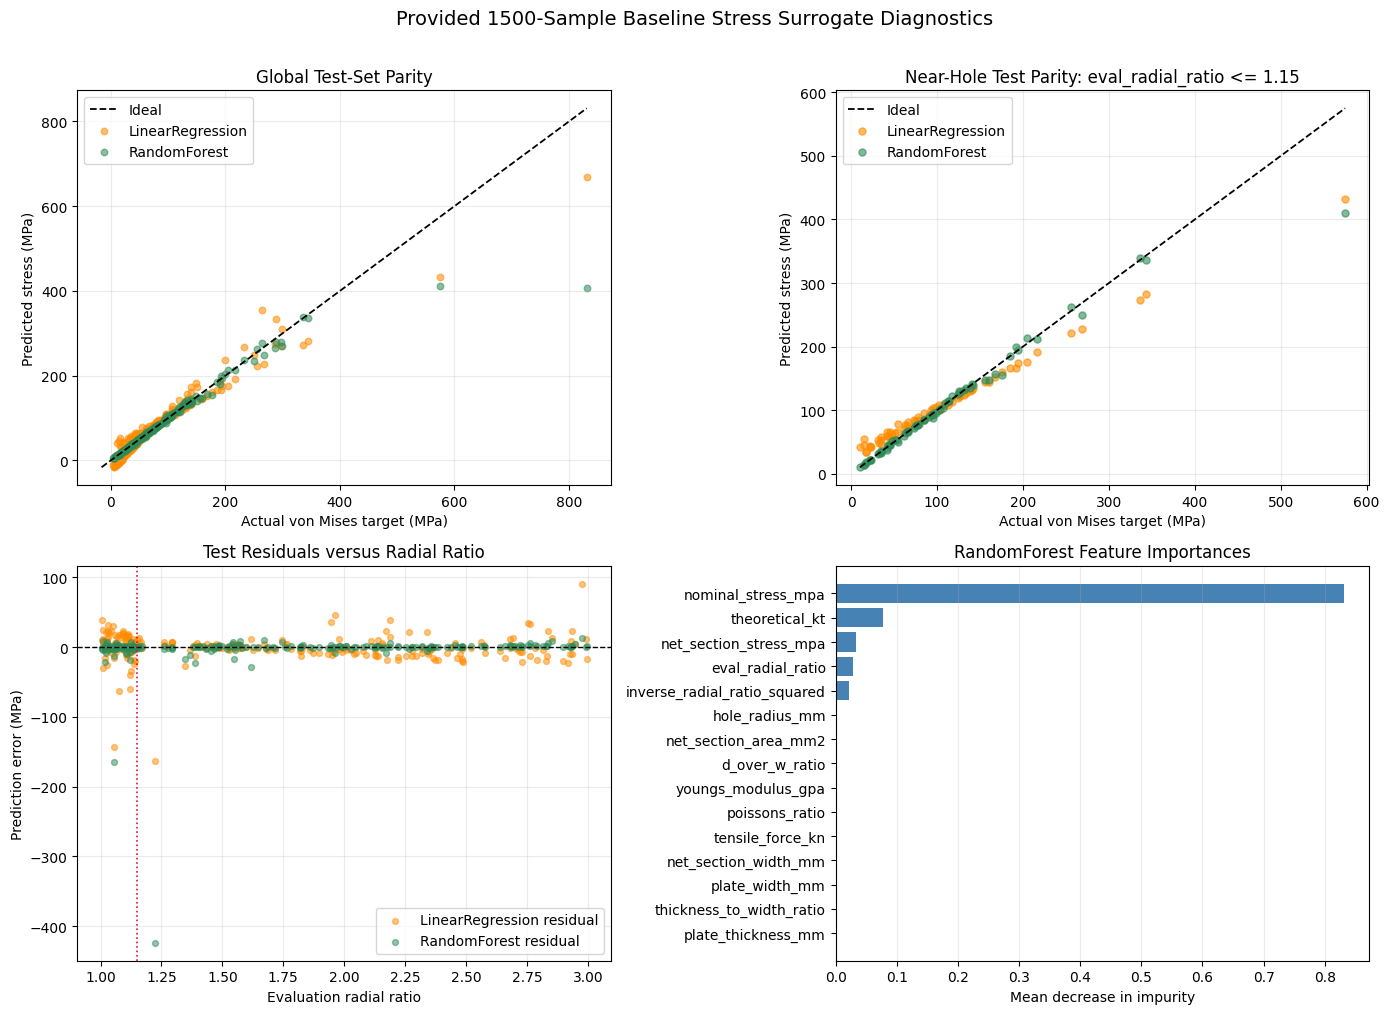

Provided 1500-sample baseline pipeline completed
Generated rows: 1500 | features used: 15
Stratified split summary:
     split  rows share  near_hole_rows radial_ratio_min radial_ratio_max
     train  1046 69.7%             314           1.0002           2.9982
validation   224 14.9%              68           1.0052           2.9891
      test   230 15.3%              71           1.0041           2.9954

Validation and held-out test metrics:
     split                                subset                        model  sample_count       R2 RMSE_MPa MAE_MPa MAPE_pct
validation                                global             LinearRegression           224 0.946234  16.1512 10.8541  28.5400
validation near-hole (eval_radial_ratio <= 1.15)             LinearRegression            68 0.919223  23.0798 16.3944  28.7828
validation                                global                 RandomForest           224 0.991646   6.3665  2.5728   2.9189
validation near-hole (eval_radial_ratio <= 1.

,split,subset,model,sample_count,R2,RMSE_MPa,MAE_MPa,MAPE_pct
0,validation,global,LinearRegression,224,0.946234,16.151152,10.854072,28.540036
1,validation,near-hole (eval_radial_ratio <= 1.15),LinearRegression,68,0.919223,23.079804,16.394376,28.782821
2,validation,global,RandomForest,224,0.991646,6.366530,2.572751,2.918906
3,validation,near-hole (eval_radial_ratio <= 1.15),RandomForest,68,0.994614,5.959372,2.946957,2.822898
4,test,global,LinearRegression,230,0.942159,21.243561,12.086895,34.623429
5,test,near-hole (eval_radial_ratio <= 1.15),LinearRegression,71,0.919998,25.595865,16.615345,32.713320
6,test,global,RandomForest,230,0.882261,30.308817,4.963159,3.690099
7,test,near-hole (eval_radial_ratio <= 1.15),RandomForest,71,0.950729,20.086983,5.134490,3.395577
8,test,global,Analytical physics reference,230,0.999904,0.867599,0.490496,0.600295
9,test,near-hole (eval_radial_ratio <= 1.15),Analytical physics reference,71,0.999877,1.002972,0.643941,0.600561


In [43]:
# Provided 1500-sample baseline surrogate pipeline.
# This section is intentionally isolated: all workflow objects use the provided_ prefix,
# and artifacts are written only under outputs/provided_baseline/.


def provided_generate_surrogate_dataset(n_samples=1500, seed=42):
    """Generate a self-contained plate-with-hole stress-concentration dataset."""
    provided_rng = np.random.default_rng(seed)
    provided_width_mm = provided_rng.uniform(100.0, 300.0, n_samples)
    provided_d_over_w_ratio = provided_rng.uniform(0.05, 0.35, n_samples)
    provided_hole_radius_mm = 0.5 * provided_width_mm * provided_d_over_w_ratio
    provided_thickness_mm = provided_rng.uniform(2.0, 12.0, n_samples)
    provided_youngs_modulus_gpa = provided_rng.uniform(180.0, 210.0, n_samples)
    provided_poissons_ratio = provided_rng.uniform(0.27, 0.33, n_samples)
    provided_tensile_force_kn = provided_rng.uniform(8.0, 85.0, n_samples)

    # Ensure that every split can support a meaningful near-hole evaluation.
    provided_near_hole_draw = provided_rng.random(n_samples) < 0.30
    provided_eval_radial_ratio = np.empty(n_samples)
    provided_eval_radial_ratio[provided_near_hole_draw] = provided_rng.uniform(
        1.0, 1.15, provided_near_hole_draw.sum()
    )
    provided_eval_radial_ratio[~provided_near_hole_draw] = provided_rng.uniform(
        1.15, 3.0, (~provided_near_hole_draw).sum()
    )

    provided_hole_diameter_mm = 2.0 * provided_hole_radius_mm
    provided_nominal_stress_mpa = (
        provided_tensile_force_kn * 1000.0
        / (provided_width_mm * provided_thickness_mm)
    )
    provided_edge_theoretical_kt = (
        3.0
        - 3.14 * provided_d_over_w_ratio
        + 3.667 * provided_d_over_w_ratio**2
        - 1.527 * provided_d_over_w_ratio**3
    )
    provided_theoretical_kt = 1.0 + (
        provided_edge_theoretical_kt - 1.0
    ) / provided_eval_radial_ratio**2
    provided_physics_reference_mpa = (
        provided_theoretical_kt * provided_nominal_stress_mpa
    )
    provided_target_mpa = provided_physics_reference_mpa * (
        1.0 + provided_rng.normal(0.0, 0.008, n_samples)
    )

    provided_raw_columns = [
        "sample_id",
        "plate_width_mm",
        "hole_radius_mm",
        "plate_thickness_mm",
        "d_over_w_ratio",
        "youngs_modulus_gpa",
        "poissons_ratio",
        "tensile_force_kn",
        "eval_radial_ratio",
        "theoretical_kt",
        "von_mises_target_mpa",
    ]
    return pd.DataFrame(
        {
            "sample_id": np.arange(1, n_samples + 1),
            "plate_width_mm": provided_width_mm,
            "hole_radius_mm": provided_hole_radius_mm,
            "plate_thickness_mm": provided_thickness_mm,
            "d_over_w_ratio": provided_d_over_w_ratio,
            "youngs_modulus_gpa": provided_youngs_modulus_gpa,
            "poissons_ratio": provided_poissons_ratio,
            "tensile_force_kn": provided_tensile_force_kn,
            "eval_radial_ratio": provided_eval_radial_ratio,
            "theoretical_kt": provided_theoretical_kt,
            "von_mises_target_mpa": provided_target_mpa,
        }
    )[provided_raw_columns]


def provided_prepare_features(provided_raw_frame):
    """Engineer physical inputs and keep the analytical reference for comparison."""
    provided_frame = provided_raw_frame.copy()
    provided_frame["hole_diameter_mm"] = 2.0 * provided_frame["hole_radius_mm"]
    provided_frame["nominal_stress_mpa"] = (
        provided_frame["tensile_force_kn"] * 1000.0
        / (provided_frame["plate_width_mm"] * provided_frame["plate_thickness_mm"])
    )
    provided_frame["net_section_width_mm"] = (
        provided_frame["plate_width_mm"] - provided_frame["hole_diameter_mm"]
    )
    provided_frame["net_section_area_mm2"] = (
        provided_frame["net_section_width_mm"] * provided_frame["plate_thickness_mm"]
    )
    provided_frame["net_section_stress_mpa"] = (
        provided_frame["tensile_force_kn"] * 1000.0
        / provided_frame["net_section_area_mm2"]
    )
    provided_frame["inverse_radial_ratio_squared"] = (
        1.0 / provided_frame["eval_radial_ratio"] ** 2
    )
    provided_frame["thickness_to_width_ratio"] = (
        provided_frame["plate_thickness_mm"] / provided_frame["plate_width_mm"]
    )
    provided_frame["physics_reference_mpa"] = (
        provided_frame["theoretical_kt"] * provided_frame["nominal_stress_mpa"]
    )

    provided_expected_kt = 1.0 + (
        (
            3.0
            - 3.14 * provided_frame["d_over_w_ratio"]
            + 3.667 * provided_frame["d_over_w_ratio"] ** 2
            - 1.527 * provided_frame["d_over_w_ratio"] ** 3
        )
        - 1.0
    ) / provided_frame["eval_radial_ratio"] ** 2
    assert np.allclose(
        provided_frame["theoretical_kt"], provided_expected_kt, rtol=0, atol=1e-12
    )
    assert np.allclose(
        provided_frame["d_over_w_ratio"],
        provided_frame["hole_diameter_mm"] / provided_frame["plate_width_mm"],
        rtol=0,
        atol=1e-12,
    )
    assert provided_frame["eval_radial_ratio"].between(1.0, 3.0).all()
    assert (provided_frame["net_section_width_mm"] > 0).all()
    assert (provided_frame["net_section_area_mm2"] > 0).all()
    assert (provided_frame["von_mises_target_mpa"] > 0).all()
    assert provided_frame.notna().all().all()
    return provided_frame


def provided_regression_metrics(provided_actual, provided_predictions):
    """Return standard regression metrics, including nonzero-target MAPE."""
    provided_actual = np.asarray(provided_actual, dtype=float).ravel()
    provided_predictions = np.asarray(provided_predictions, dtype=float).ravel()
    assert provided_actual.shape == provided_predictions.shape
    assert np.isfinite(provided_actual).all()
    assert np.isfinite(provided_predictions).all()
    assert (provided_actual != 0).all(), "MAPE requires nonzero targets."
    return {
        "sample_count": len(provided_actual),
        "R2": r2_score(provided_actual, provided_predictions),
        "RMSE_MPa": np.sqrt(mean_squared_error(provided_actual, provided_predictions)),
        "MAE_MPa": mean_absolute_error(provided_actual, provided_predictions),
        "MAPE_pct": float(
            np.mean(np.abs((provided_predictions - provided_actual) / provided_actual))
            * 100.0
        ),
    }


def provided_main():
    provided_seed = 42
    provided_n_samples = 1500
    provided_output_dir = Path("outputs/provided_baseline")
    provided_output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Generate and validate the provided 1500-sample source data.
    provided_raw_df = provided_generate_surrogate_dataset(
        n_samples=provided_n_samples, seed=provided_seed
    )
    provided_feature_df = provided_prepare_features(provided_raw_df)
    provided_feature_columns = [
        "plate_width_mm",
        "hole_radius_mm",
        "plate_thickness_mm",
        "d_over_w_ratio",
        "youngs_modulus_gpa",
        "poissons_ratio",
        "tensile_force_kn",
        "eval_radial_ratio",
        "theoretical_kt",
        "nominal_stress_mpa",
        "net_section_stress_mpa",
        "net_section_width_mm",
        "net_section_area_mm2",
        "inverse_radial_ratio_squared",
        "thickness_to_width_ratio",
    ]
    provided_target_column = "von_mises_target_mpa"
    provided_physics_column = "physics_reference_mpa"
    assert provided_feature_df[provided_feature_columns + [provided_target_column]].notna().all().all()

    # 2. Stratify jointly by geometry and radial bands, then split 70/15/15.
    provided_feature_df["geometry_stratum"] = pd.qcut(
        provided_feature_df["d_over_w_ratio"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    provided_feature_df["radial_stratum"] = pd.cut(
        provided_feature_df["eval_radial_ratio"],
        bins=[1.0, 1.15, 1.5, 2.0, 3.0],
        labels=False,
        include_lowest=True,
        right=True,
    )
    provided_feature_df["split_stratum"] = (
        provided_feature_df["geometry_stratum"].astype(str)
        + "_"
        + provided_feature_df["radial_stratum"].astype(str)
    )

    provided_split_rng = np.random.default_rng(provided_seed + 1)
    provided_train_parts, provided_validation_parts, provided_test_parts = [], [], []
    for _, provided_stratum_df in provided_feature_df.groupby(
        "split_stratum", sort=True
    ):
        provided_indices = provided_split_rng.permutation(
            provided_stratum_df.index.to_numpy()
        )
        provided_stratum_size = len(provided_indices)
        provided_n_train = int(round(0.70 * provided_stratum_size))
        provided_n_validation = int(round(0.15 * provided_stratum_size))
        provided_train_parts.append(
            provided_feature_df.loc[provided_indices[:provided_n_train]]
        )
        provided_validation_parts.append(
            provided_feature_df.loc[
                provided_indices[provided_n_train : provided_n_train + provided_n_validation]
            ]
        )
        provided_test_parts.append(
            provided_feature_df.loc[
                provided_indices[provided_n_train + provided_n_validation :]
            ]
        )

    provided_train_source_df = pd.concat(provided_train_parts)
    provided_validation_source_df = pd.concat(provided_validation_parts)
    provided_test_source_df = pd.concat(provided_test_parts)
    provided_train_source_ids = set(provided_train_source_df.index)
    provided_validation_source_ids = set(provided_validation_source_df.index)
    provided_test_source_ids = set(provided_test_source_df.index)
    assert provided_train_source_ids.isdisjoint(provided_validation_source_ids)
    assert provided_train_source_ids.isdisjoint(provided_test_source_ids)
    assert provided_validation_source_ids.isdisjoint(provided_test_source_ids)
    assert len(
        provided_train_source_ids
        | provided_validation_source_ids
        | provided_test_source_ids
    ) == provided_n_samples

    provided_train_df = (
        provided_train_source_df.sample(frac=1.0, random_state=provided_seed)
        .reset_index(drop=True)
    )
    provided_validation_df = (
        provided_validation_source_df.sample(frac=1.0, random_state=provided_seed)
        .reset_index(drop=True)
    )
    provided_test_df = (
        provided_test_source_df.sample(frac=1.0, random_state=provided_seed)
        .reset_index(drop=True)
    )
    assert len(provided_train_df) + len(provided_validation_df) + len(provided_test_df) == provided_n_samples
    assert abs(len(provided_train_df) / provided_n_samples - 0.70) < 0.01
    assert abs(len(provided_validation_df) / provided_n_samples - 0.15) < 0.01
    assert abs(len(provided_test_df) / provided_n_samples - 0.15) < 0.01

    # 3. Fit LinearRegression and RandomForest on training data only.
    provided_linear_model = LinearRegression()
    provided_linear_model.fit(
        provided_train_df[provided_feature_columns],
        provided_train_df[provided_target_column].to_numpy(),
    )
    provided_rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=provided_seed,
        n_jobs=1,
        min_samples_leaf=2,
    )
    provided_rf_model.fit(
        provided_train_df[provided_feature_columns],
        provided_train_df[provided_target_column].to_numpy(),
    )

    provided_predictions = {}
    for provided_model_name, provided_model in [
        ("LinearRegression", provided_linear_model),
        ("RandomForest", provided_rf_model),
    ]:
        provided_predictions[provided_model_name] = {
            provided_split_name: provided_model.predict(
                provided_split_df[provided_feature_columns]
            )
            for provided_split_name, provided_split_df in [
                ("train", provided_train_df),
                ("validation", provided_validation_df),
                ("test", provided_test_df),
            ]
        }

    # 4. Evaluate global and near-hole subsets on validation and held-out test data.
    provided_metric_rows = []
    for provided_split_name, provided_split_df in [
        ("validation", provided_validation_df),
        ("test", provided_test_df),
    ]:
        provided_actual = provided_split_df[provided_target_column].to_numpy()
        provided_near_hole_mask = (
            provided_split_df["eval_radial_ratio"].to_numpy() <= 1.15
        )
        assert provided_near_hole_mask.any()
        for provided_model_name, provided_model_predictions in provided_predictions.items():
            provided_metric_rows.append(
                {
                    "split": provided_split_name,
                    "subset": "global",
                    "model": provided_model_name,
                    **provided_regression_metrics(
                        provided_actual, provided_model_predictions[provided_split_name]
                    ),
                }
            )
            provided_metric_rows.append(
                {
                    "split": provided_split_name,
                    "subset": "near-hole (eval_radial_ratio <= 1.15)",
                    "model": provided_model_name,
                    **provided_regression_metrics(
                        provided_actual[provided_near_hole_mask],
                        provided_model_predictions[provided_split_name][provided_near_hole_mask],
                    ),
                }
            )

    provided_test_actual = provided_test_df[provided_target_column].to_numpy()
    provided_test_physics_reference = provided_test_df[provided_physics_column].to_numpy()
    provided_test_near_hole_mask = (
        provided_test_df["eval_radial_ratio"].to_numpy() <= 1.15
    )
    provided_metric_rows.extend(
        [
            {
                "split": "test",
                "subset": "global",
                "model": "Analytical physics reference",
                **provided_regression_metrics(
                    provided_test_actual, provided_test_physics_reference
                ),
            },
            {
                "split": "test",
                "subset": "near-hole (eval_radial_ratio <= 1.15)",
                "model": "Analytical physics reference",
                **provided_regression_metrics(
                    provided_test_actual[provided_test_near_hole_mask],
                    provided_test_physics_reference[provided_test_near_hole_mask],
                ),
            },
        ]
    )
    provided_metric_table = pd.DataFrame(provided_metric_rows)[
        [
            "split",
            "subset",
            "model",
            "sample_count",
            "R2",
            "RMSE_MPa",
            "MAE_MPa",
            "MAPE_pct",
        ]
    ]

    # 5. Feature importances, diagnostics, and test-prediction export.
    provided_rf_feature_importance = (
        pd.DataFrame(
            {
                "feature": provided_feature_columns,
                "importance": provided_rf_model.feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    provided_linear_coefficients = (
        pd.DataFrame(
            {
                "feature": provided_feature_columns,
                "coefficient": provided_linear_model.coef_,
                "absolute_coefficient": np.abs(provided_linear_model.coef_),
            }
        )
        .sort_values("absolute_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    provided_test_linear_predictions = provided_predictions["LinearRegression"]["test"]
    provided_test_rf_predictions = provided_predictions["RandomForest"]["test"]
    provided_test_linear_residuals = provided_test_linear_predictions - provided_test_actual
    provided_test_rf_residuals = provided_test_rf_predictions - provided_test_actual
    provided_plot_min = min(
        provided_test_actual.min(),
        provided_test_linear_predictions.min(),
        provided_test_rf_predictions.min(),
        provided_test_physics_reference.min(),
    )
    provided_plot_max = max(
        provided_test_actual.max(),
        provided_test_linear_predictions.max(),
        provided_test_rf_predictions.max(),
        provided_test_physics_reference.max(),
    )
    provided_diagnostic_figure, provided_diagnostic_axes = plt.subplots(
        2, 2, figsize=(14, 10)
    )

    provided_diagnostic_axes[0, 0].plot(
        [provided_plot_min, provided_plot_max],
        [provided_plot_min, provided_plot_max],
        "k--",
        linewidth=1.3,
        label="Ideal",
    )
    provided_diagnostic_axes[0, 0].scatter(
        provided_test_actual,
        provided_test_linear_predictions,
        s=22,
        alpha=0.55,
        color="darkorange",
        label="LinearRegression",
    )
    provided_diagnostic_axes[0, 0].scatter(
        provided_test_actual,
        provided_test_rf_predictions,
        s=22,
        alpha=0.55,
        color="seagreen",
        label="RandomForest",
    )
    provided_diagnostic_axes[0, 0].set_title("Global Test-Set Parity")
    provided_diagnostic_axes[0, 0].set_xlabel("Actual von Mises target (MPa)")
    provided_diagnostic_axes[0, 0].set_ylabel("Predicted stress (MPa)")
    provided_diagnostic_axes[0, 0].grid(alpha=0.25)
    provided_diagnostic_axes[0, 0].legend()

    provided_near_hole_actual = provided_test_actual[provided_test_near_hole_mask]
    provided_near_hole_linear = provided_test_linear_predictions[provided_test_near_hole_mask]
    provided_near_hole_rf = provided_test_rf_predictions[provided_test_near_hole_mask]
    provided_near_min = min(
        provided_near_hole_actual.min(),
        provided_near_hole_linear.min(),
        provided_near_hole_rf.min(),
    )
    provided_near_max = max(
        provided_near_hole_actual.max(),
        provided_near_hole_linear.max(),
        provided_near_hole_rf.max(),
    )
    provided_diagnostic_axes[0, 1].plot(
        [provided_near_min, provided_near_max],
        [provided_near_min, provided_near_max],
        "k--",
        linewidth=1.3,
        label="Ideal",
    )
    provided_diagnostic_axes[0, 1].scatter(
        provided_near_hole_actual,
        provided_near_hole_linear,
        s=26,
        alpha=0.60,
        color="darkorange",
        label="LinearRegression",
    )
    provided_diagnostic_axes[0, 1].scatter(
        provided_near_hole_actual,
        provided_near_hole_rf,
        s=26,
        alpha=0.60,
        color="seagreen",
        label="RandomForest",
    )
    provided_diagnostic_axes[0, 1].set_title(
        "Near-Hole Test Parity: eval_radial_ratio <= 1.15"
    )
    provided_diagnostic_axes[0, 1].set_xlabel("Actual von Mises target (MPa)")
    provided_diagnostic_axes[0, 1].set_ylabel("Predicted stress (MPa)")
    provided_diagnostic_axes[0, 1].grid(alpha=0.25)
    provided_diagnostic_axes[0, 1].legend()

    provided_diagnostic_axes[1, 0].axhline(
        0.0, color="black", linestyle="--", linewidth=1.0
    )
    provided_diagnostic_axes[1, 0].scatter(
        provided_test_df["eval_radial_ratio"],
        provided_test_linear_residuals,
        s=18,
        alpha=0.50,
        color="darkorange",
        label="LinearRegression residual",
    )
    provided_diagnostic_axes[1, 0].scatter(
        provided_test_df["eval_radial_ratio"],
        provided_test_rf_residuals,
        s=18,
        alpha=0.50,
        color="seagreen",
        label="RandomForest residual",
    )
    provided_diagnostic_axes[1, 0].axvline(
        1.15, color="crimson", linestyle=":", linewidth=1.2
    )
    provided_diagnostic_axes[1, 0].set_title("Test Residuals versus Radial Ratio")
    provided_diagnostic_axes[1, 0].set_xlabel("Evaluation radial ratio")
    provided_diagnostic_axes[1, 0].set_ylabel("Prediction error (MPa)")
    provided_diagnostic_axes[1, 0].grid(alpha=0.25)
    provided_diagnostic_axes[1, 0].legend()

    provided_importance_plot = provided_rf_feature_importance.sort_values(
        "importance", ascending=True
    )
    provided_diagnostic_axes[1, 1].barh(
        provided_importance_plot["feature"],
        provided_importance_plot["importance"],
        color="steelblue",
    )
    provided_diagnostic_axes[1, 1].set_title("RandomForest Feature Importances")
    provided_diagnostic_axes[1, 1].set_xlabel("Mean decrease in impurity")
    provided_diagnostic_axes[1, 1].grid(axis="x", alpha=0.25)
    provided_diagnostic_figure.suptitle(
        "Provided 1500-Sample Baseline Stress Surrogate Diagnostics",
        y=1.01,
        fontsize=14,
    )
    provided_diagnostic_figure.tight_layout()
    provided_diagnostics_path = (
        provided_output_dir / "stress_surrogate_diagnostics.png"
    )
    provided_diagnostic_figure.savefig(
        provided_diagnostics_path, dpi=160, bbox_inches="tight"
    )
    plt.show()

    provided_prediction_df = provided_test_df[
        ["sample_id", "d_over_w_ratio", "eval_radial_ratio"]
    ].copy()
    provided_prediction_df["near_hole"] = provided_test_near_hole_mask
    provided_prediction_df["actual_von_mises_target_mpa"] = provided_test_actual
    provided_prediction_df["analytical_physics_reference_mpa"] = (
        provided_test_physics_reference
    )
    provided_prediction_df["linear_regression_prediction_mpa"] = (
        provided_test_linear_predictions
    )
    provided_prediction_df["random_forest_prediction_mpa"] = provided_test_rf_predictions
    provided_prediction_df["linear_regression_error_mpa"] = provided_test_linear_residuals
    provided_prediction_df["random_forest_error_mpa"] = provided_test_rf_residuals
    provided_predictions_path = (
        provided_output_dir / "stress_surrogate_test_predictions.csv"
    )
    provided_prediction_df.to_csv(provided_predictions_path, index=False)

    provided_split_summary = pd.DataFrame(
        {
            "split": ["train", "validation", "test"],
            "rows": [
                len(provided_train_df),
                len(provided_validation_df),
                len(provided_test_df),
            ],
            "share": [
                len(provided_train_df) / provided_n_samples,
                len(provided_validation_df) / provided_n_samples,
                len(provided_test_df) / provided_n_samples,
            ],
            "near_hole_rows": [
                (provided_train_df["eval_radial_ratio"] <= 1.15).sum(),
                (provided_validation_df["eval_radial_ratio"] <= 1.15).sum(),
                (provided_test_df["eval_radial_ratio"] <= 1.15).sum(),
            ],
            "radial_ratio_min": [
                provided_train_df["eval_radial_ratio"].min(),
                provided_validation_df["eval_radial_ratio"].min(),
                provided_test_df["eval_radial_ratio"].min(),
            ],
            "radial_ratio_max": [
                provided_train_df["eval_radial_ratio"].max(),
                provided_validation_df["eval_radial_ratio"].max(),
                provided_test_df["eval_radial_ratio"].max(),
            ],
        }
    )

    print("Provided 1500-sample baseline pipeline completed")
    print(
        f"Generated rows: {len(provided_raw_df)} | "
        f"features used: {len(provided_feature_columns)}"
    )
    print("Stratified split summary:")
    print(
        provided_split_summary.to_string(
            index=False,
            formatters={
                "share": "{:.1%}".format,
                "radial_ratio_min": "{:.4f}".format,
                "radial_ratio_max": "{:.4f}".format,
            },
        )
    )
    print("\nValidation and held-out test metrics:")
    print(
        provided_metric_table.to_string(
            index=False,
            formatters={
                "R2": "{:.6f}".format,
                "RMSE_MPa": "{:.4f}".format,
                "MAE_MPa": "{:.4f}".format,
                "MAPE_pct": "{:.4f}".format,
            },
        )
    )
    print("\nTop RandomForest feature importances:")
    print(
        provided_rf_feature_importance.head(10).to_string(
            index=False, formatters={"importance": "{:.6f}".format}
        )
    )
    print("\nTop LinearRegression coefficients by absolute magnitude:")
    print(
        provided_linear_coefficients.head(10).to_string(
            index=False,
            formatters={"coefficient": "{:.6f}".format},
        )
    )
    print(f"Diagnostics artifact: {provided_diagnostics_path.resolve()}")
    print(f"Prediction artifact: {provided_predictions_path.resolve()}")

    return {
        "raw_df": provided_raw_df,
        "train_df": provided_train_df,
        "validation_df": provided_validation_df,
        "test_df": provided_test_df,
        "metric_table": provided_metric_table,
        "rf_feature_importance": provided_rf_feature_importance,
        "linear_coefficients": provided_linear_coefficients,
        "diagnostics_path": provided_diagnostics_path,
        "predictions_path": provided_predictions_path,
    }


# Explicit notebook execution; no __name__ guard is needed in Deepnote.
provided_results = provided_main()
provided_results["metric_table"]

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=3a0605de-940c-4b15-8bdc-739c00e3649d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>